#### **프로젝트 개요**
## 부산 15분 아동돌봄 생활권 구축: 들락날락 중심 허브-위성형 방과후 돌봄 연계 모델

#### 돌봄 수요 및 공급 지도를 만들고, E2SFCA 기반 접근성을 분석합니다.
* 수요자: 초등학생 인구, 만 7~12세

  (중학생은 스스로 보호 능력이 있고, 영유아는 시설까지 스스로 접근하기 어려워 제외)
* 임계거리: 750m (이 거리 안에 있으면 이용 가능하다고 보는 기준)
* 거리 계산: 도로망 네트워크 거리 기준
* E2SFCA 계산
  - 1단계: 시설별 수요 대비 공급비 계산. `시설 j의 공급비 = 1 / 750m 안의 가중 아동 인구`
  - 2단계: 격자별 접근성 계산. `격자 i의 접근성 = 주변 시설들의 공급비 합`
  - 거리 가중치는 가우시안 함수 사용(거리가 멀어질수록 가중치 낮춤)
* 최종 행정동 접근성 = 해당 행정동 안에 포함된 100m 격자 접근성의 산술평균



In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 폰트 설정 사용하는 환경에 따라 수정하시면 됩니다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 초등학생 인구 100m 격자 지도

In [2]:
# 인구 100m 격자 데이터 불러오기

gdf = gpd.read_file("busan_100m_population_5179.gpkg")

# 인구값 컬럼
pop_col = "val"

# 인구값 숫자형 변환
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce")

# 좌표계 확인
print("좌표계:", gdf.crs)
print("컬럼 목록:", gdf.columns.tolist())
print(gdf[[pop_col]].describe())

좌표계: EPSG:5179
컬럼 목록: ['gid', 'val', 'pop_class', 'geometry']
                val
count  10825.000000
mean      13.008776
std       23.154212
min        0.000000
25%        0.000000
50%        6.000000
75%       17.000000
max      483.000000


In [3]:
# =========================
# 3. QGIS SLD 스타일 정보
# =========================

bins = [-np.inf, 7, 11, 16, 22, 27, 37, np.inf]

labels = [
    "7 이하",
    "7 - 11 이하",
    "11 - 16 이하",
    "16 - 22 이하",
    "22 - 27 이하",
    "27 - 37 이하",
    "37 이상"
]

colors = {
    "7 이하": "#FFF5EB",
    "7 - 11 이하": "#FEE6CE",
    "11 - 16 이하": "#FDD0A2",
    "16 - 22 이하": "#FDAE6B",
    "22 - 27 이하": "#FD8D3C",
    "27 - 37 이하": "#F16913",
    "37 이상": "#CC4704"
}

# 인구 구간 생성
gdf["pop_class"] = pd.cut(
    gdf[pop_col],
    bins=bins,
    labels=labels,
    right=True
)

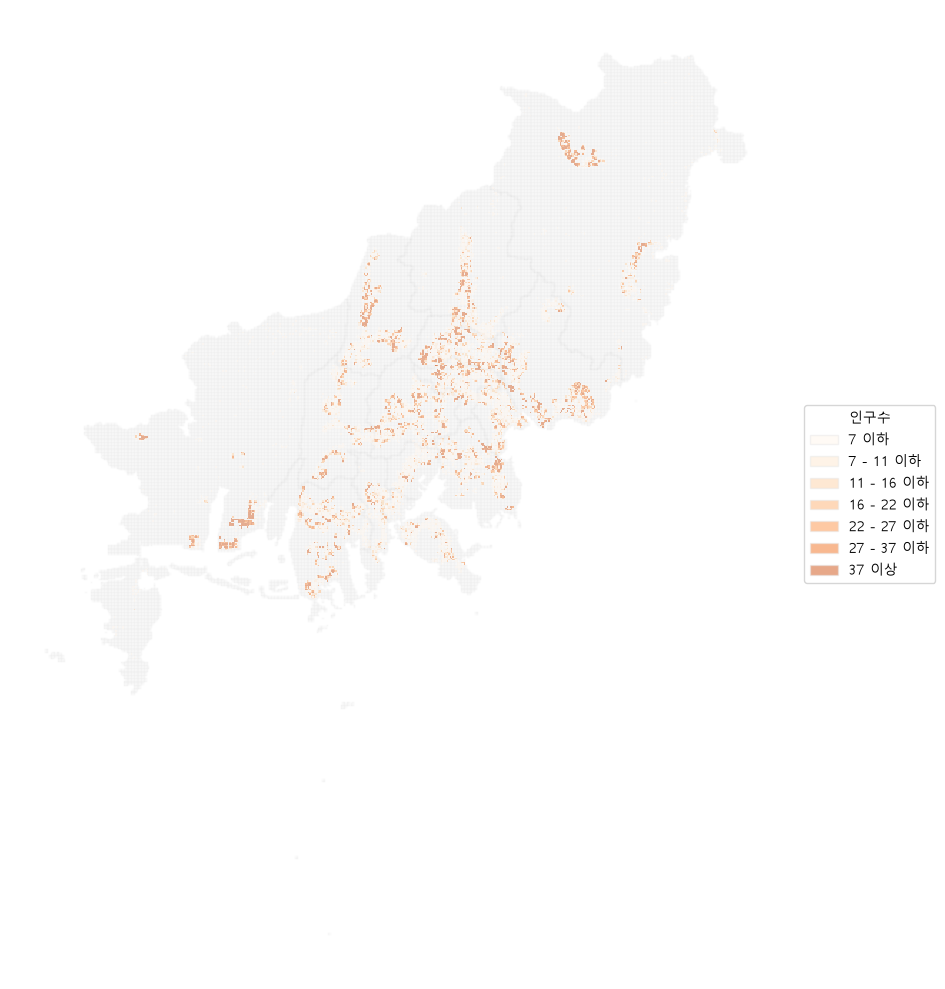

In [5]:

fig, ax = plt.subplots(figsize=(10, 10))

# 결측값 / 통계 없음
gdf[gdf["pop_class"].isna()].plot(
    ax=ax,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1
)

# 인구 구간별 색상 적용
for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.47
        )

# 범례 생성
legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.47,
        label=label
    )
    for label in labels
]

ax.legend(
    handles=legend_handles,
    title="인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_axis_off()
plt.tight_layout()
#fig.savefig("초등학생인구지도.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 초등학생 인구 100m 격자 지도 + 다함께돌봄센터

전체 센터 수: 76
점 찍을 센터 수: 76
gdf 좌표계: EPSG:5179
center_gdf 좌표계: EPSG:5179
center_gdf 범위: [1121963.82514546 1675298.66141663 1156825.58408406 1704621.14233626]


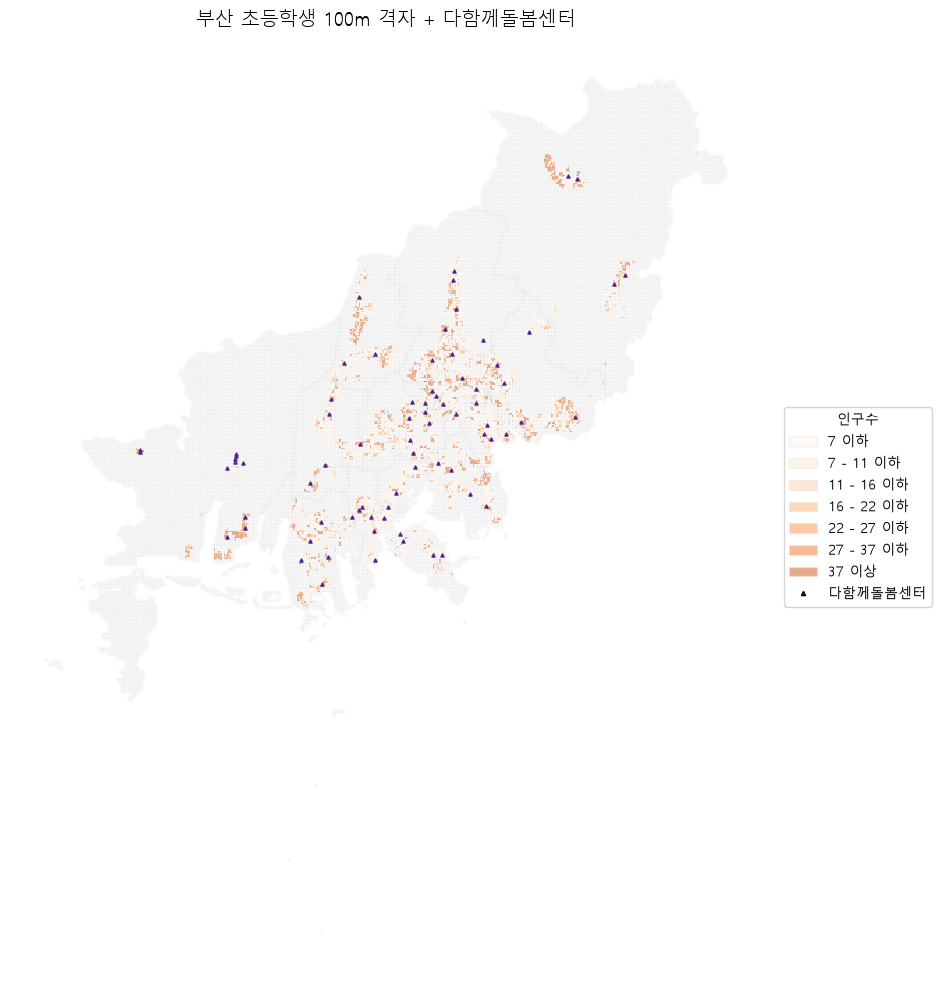

In [4]:
# =========================
# 인구 격자 + 다함께돌봄센터
# =========================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

center_df = pd.read_csv("다함께돌봄센터_현황.csv", encoding="utf-8-sig")

# lon, lat 숫자형으로 변환
center_df["lon"] = pd.to_numeric(center_df["lon"], errors="coerce")
center_df["lat"] = pd.to_numeric(center_df["lat"], errors="coerce")

# 좌표 있는 것만 사용
center_ok = center_df.dropna(subset=["lon", "lat"]).copy()

print("전체 센터 수:", len(center_df))
print("점 찍을 센터 수:", len(center_ok))

# 점 데이터 GeoDataFrame 만들기
center_gdf = gpd.GeoDataFrame(
    center_ok,
    geometry=gpd.points_from_xy(center_ok["lon"], center_ok["lat"]),
    crs="EPSG:4326"
)

# 격자 지도 gdf와 좌표계 맞추기
center_gdf = center_gdf.to_crs(gdf.crs)

print("gdf 좌표계:", gdf.crs)
print("center_gdf 좌표계:", center_gdf.crs)
print("center_gdf 범위:", center_gdf.total_bounds)

# 지도 만들자
fig2, ax2 = plt.subplots(figsize=(10, 10))

# 결측값 / 통계 없음
gdf[gdf["pop_class"].isna()].plot(
    ax=ax2,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1
)

# 인구 구간별 색상 적용
for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax2,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.47
        )

# 새 지도2 위에 돌봄센터 점 찍기
center_gdf.plot(
    ax=ax2,
    color="#54278F",
    markersize=5,
    marker="^",
    zorder=10
)

# 범례 만들기
legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.47,
        label=label
    )
    for label in labels
]

center_handle = plt.Line2D(
    [],
    [],
    marker="^",
    color="black",
    markerfacecolor="#54278F",
    markersize=3,
    linestyle="None",
    label="다함께돌봄센터"
)

legend_handles.append(center_handle)

ax2.legend(
    handles=legend_handles,
    title="인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax2.set_title("부산 초등학생 100m 격자 + 다함께돌봄센터", fontsize=14)
ax2.set_axis_off()

plt.tight_layout()
#fig2.savefig("초등학생인구_다함께돌봄센터.png", dpi=300, bbox_inches="tight", facecolor="white") #이미지 저장용
plt.show()

# 초등학생 인구 100m 격자 지도 + 들락날락

전체 들락날락 수: 102
점 찍을 수: 102
gdf 좌표계: EPSG:5179
dlnl_gdf 좌표계: EPSG:5179
gdf 범위: [1115100. 1650000. 1164200. 1711700.]
dlnl_gdf 범위: [1125115.99190242 1673803.6601909  1158078.87886551 1708557.32608938]


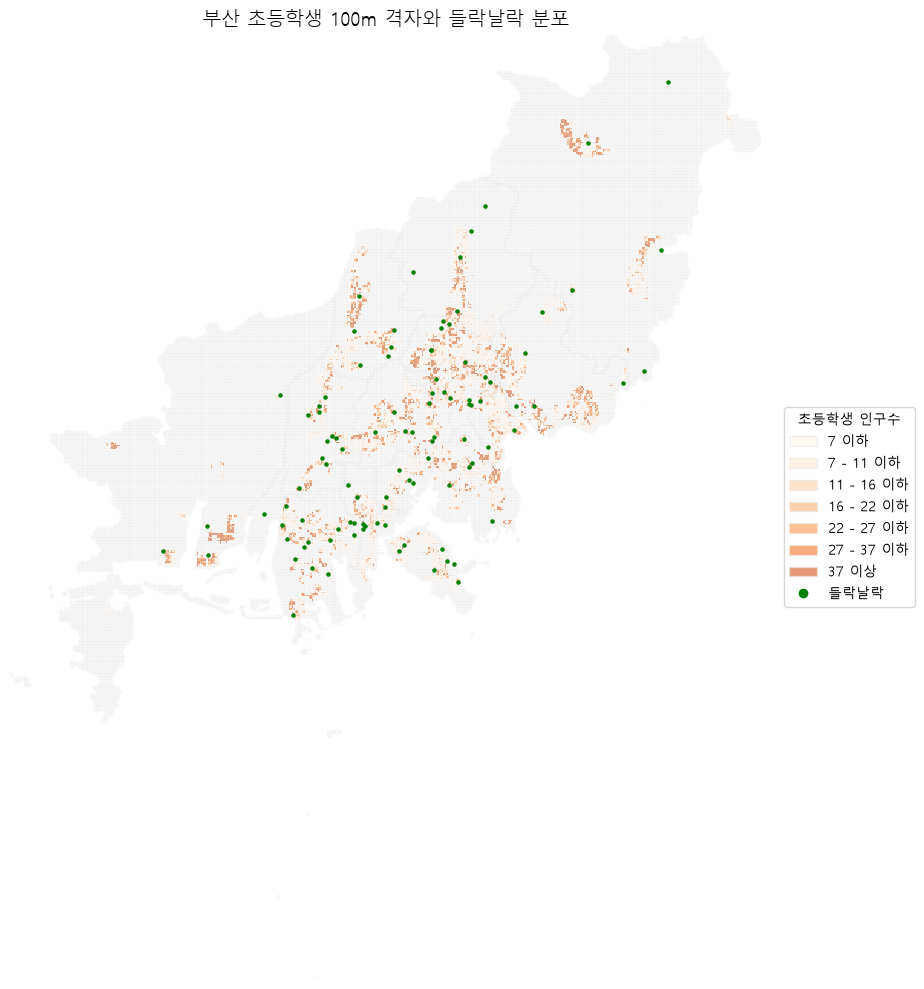

In [5]:
# =========================
# 초등학생 100m 인구 격자지도 + 들락날락
# =========================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dlnl_df = pd.read_csv("busan_dlnl_homepage_102_coord.csv", encoding="utf-8-sig")


dlnl_df["위도"] = pd.to_numeric(dlnl_df["위도"], errors="coerce")
dlnl_df["경도"] = pd.to_numeric(dlnl_df["경도"], errors="coerce")


dlnl_ok = dlnl_df.dropna(subset=["위도", "경도"]).copy()

print("전체 들락날락 수:", len(dlnl_df))
print("점 찍을 수:", len(dlnl_ok))


dlnl_gdf = gpd.GeoDataFrame(
    dlnl_ok,
    geometry=gpd.points_from_xy(dlnl_ok["경도"], dlnl_ok["위도"]),
    crs="EPSG:4326"
)


dlnl_gdf = dlnl_gdf.to_crs(gdf.crs)

print("gdf 좌표계:", gdf.crs)
print("dlnl_gdf 좌표계:", dlnl_gdf.crs)
print("gdf 범위:", gdf.total_bounds)
print("dlnl_gdf 범위:", dlnl_gdf.total_bounds)

fig3, ax3 = plt.subplots(figsize=(10, 10))


gdf[gdf["pop_class"].isna()].plot(
    ax=ax3,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1,
    zorder=1
)

for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax3,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.55,
            zorder=2
        )

dlnl_gdf.plot(
    ax=ax3,
    color="green",
    markersize=5,
    marker="o",
    zorder=10,
    label="들락날락"
)


minx, miny, maxx, maxy = gdf.total_bounds
ax3.set_xlim(minx, maxx)
ax3.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.55,
        label=label
    )
    for label in labels
]

dlnl_handle = plt.Line2D(
    [],
    [],
    marker="o",
    color="white",
    markerfacecolor="green",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="들락날락"
)

legend_handles.append(dlnl_handle)

ax3.legend(
    handles=legend_handles,
    title="초등학생 인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax3.set_title("부산 초등학생 100m 격자와 들락날락 분포", fontsize=14)
ax3.set_axis_off()

plt.tight_layout()
#fig3.savefig("초등학생인구_들락날락.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 초등학생 인구 100m 격자 지도 + 들락날락 + 다함께 돌봄센터

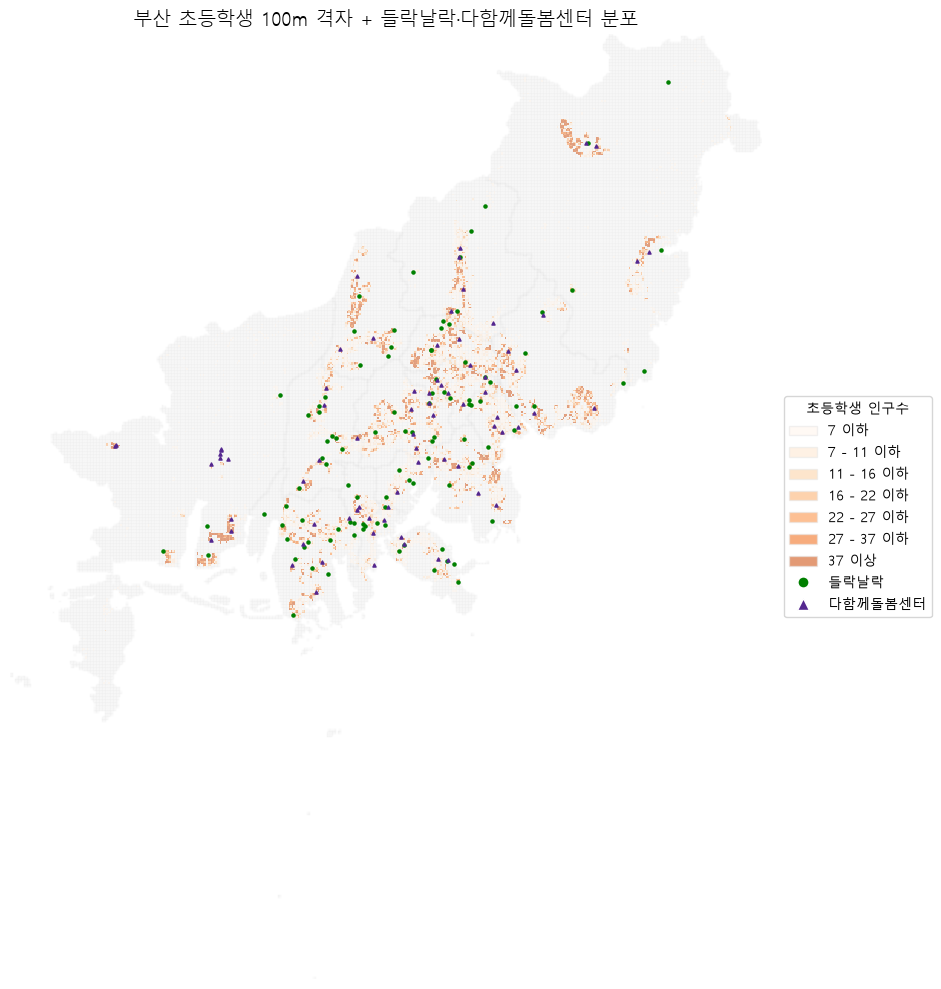

In [6]:
# =========================
# 초등학생 100m 인구 격자지도 + 들락날락 + 다함께돌봄센터
# =========================

fig4, ax4 = plt.subplots(figsize=(10, 10))

gdf[gdf["pop_class"].isna()].plot(
    ax=ax4,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1,
    zorder=1
)

for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax4,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.55,
            zorder=2
        )

dlnl_gdf.plot(
    ax=ax4,
    color="green",
    markersize=5,
    marker="o",
    zorder=10,
    label="들락날락"
)

center_gdf.plot(
    ax=ax4,
    color="#54278F",
    markersize=5,
    marker="^",
    zorder=11,
    label="다함께돌봄센터"
)

minx, miny, maxx, maxy = gdf.total_bounds
ax4.set_xlim(minx, maxx)
ax4.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.55,
        label=label
    )
    for label in labels
]

dlnl_handle = plt.Line2D(
    [],
    [],
    marker="o",
    color="white",
    markerfacecolor="green",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="들락날락"
)

center_handle = plt.Line2D(
    [],
    [],
    marker="^",
    color="white",
    markerfacecolor="#54278F",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="다함께돌봄센터"
)

legend_handles.append(dlnl_handle)
legend_handles.append(center_handle)

ax4.legend(
    handles=legend_handles,
    title="초등학생 인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax4.set_title("부산 초등학생 100m 격자 + 들락날락·다함께돌봄센터 분포", fontsize=14)
ax4.set_axis_off()

plt.tight_layout()
#fig4.savefig("초등학생인구_들락날락_다함께돌봄센터.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 초등학생 인구 100m 격자 지도 + 다함께돌봄센터 + 들락날락 + 지역아동센터

Index(['연번', '구군명', '법정동', '행정동', '기관명', '주소', '연락처', '운영요일', '휴무일', '(학기)시작',
       '(학기)종료', '(방학)시작', '(방학)종료', '이용대상', '이용요금', 'full_addr', 'lon', 'lat',
       'match_type', 'matched_query'],
      dtype='str')
   연번 구군명     법정동    행정동         기관명                           주소  \
0   1  중구   보수동1가    보수동  동광해들지역아동센터             중구 중구로 63(보수동1가)   
1   2  중구   보수동3가    보수동    희망지역아동센터         중구 흑교로45번길 13(보수동3가)   
2   3  중구     영주동   영주1동    지수지역아동센터          중구 대영로 242번길 4(영주동)   
3   4  서구    남부민동  남부민2동    해강지역아동센터         서구 해돋이로 71, 4층(남부민동)   
4   5  서구  동대신동3가  동대신3동    대신지역아동센터  서구 구덕로 346번길 17, 3층(동대신동3가)   

             연락처 운영요일        휴무일 (학기)시작 (학기)종료 (방학)시작 (방학)종료  \
0   051-246-7755  월-금  토, 일, 공휴일  10:00  19:00  10:00  19:00   
1   051-243-0912  월-금  토, 일, 공휴일  11:00  20:00  11:00  20:00   
2  070-8141-1001  월-금  토, 일, 공휴일  10:30  19:30  10:30  19:30   
3   051-241-1161  월-금  토, 일, 공휴일  11:00  20:00  11:00  20:00   
4   051-241-5681  월-금  토, 일, 공휴일  10:00  20:00  

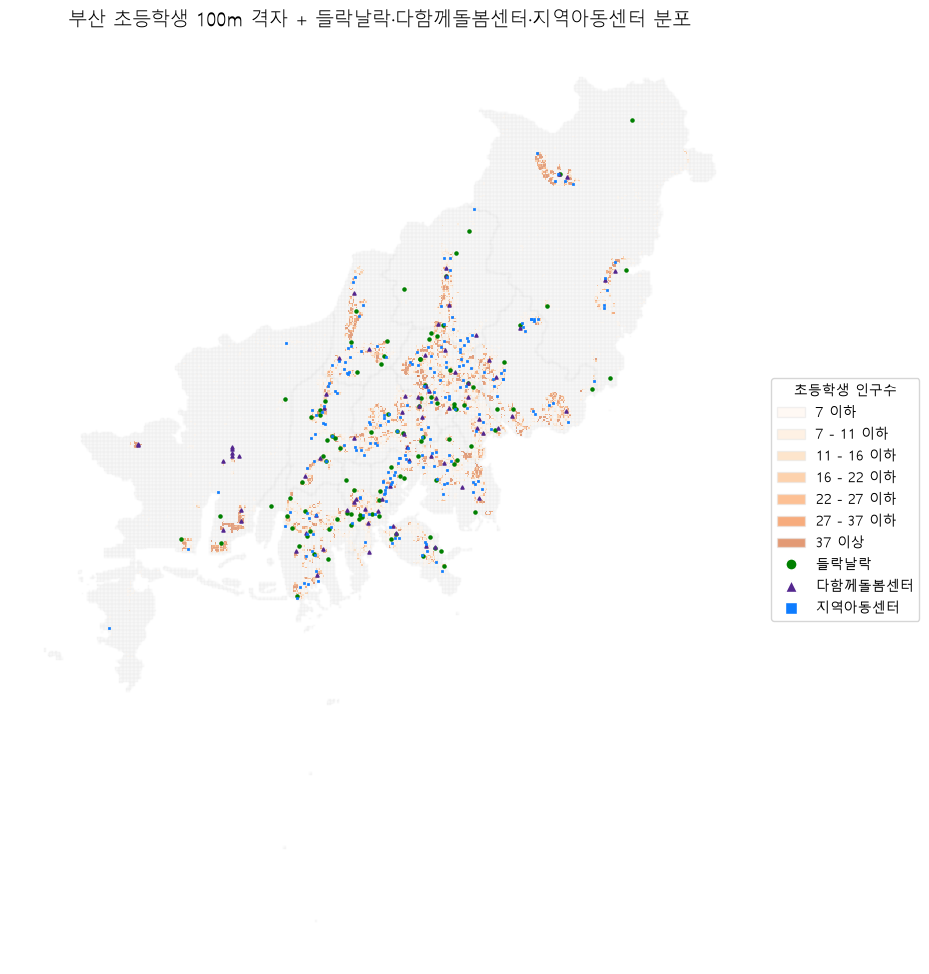

In [7]:
# =========================
# + 지역아동센터
# =========================

local_df = pd.read_csv("지역아동센터_시설현황.csv", encoding="utf-8-sig")

print(local_df.columns)
print(local_df.head())

local_df["lon"] = pd.to_numeric(local_df["lon"], errors="coerce")
local_df["lat"] = pd.to_numeric(local_df["lat"], errors="coerce")

local_ok = local_df.dropna(subset=["lon", "lat"]).copy()

print("지역아동센터 전체 수:", len(local_df))
print("점 찍을 수:", len(local_ok))

local_gdf = gpd.GeoDataFrame(
    local_ok,
    geometry=gpd.points_from_xy(local_ok["lon"], local_ok["lat"]),
    crs="EPSG:4326"
)

local_gdf = local_gdf.to_crs(gdf.crs)

print("local_gdf 범위:", local_gdf.total_bounds)

fig5, ax5 = plt.subplots(figsize=(10, 10))

gdf[gdf["pop_class"].isna()].plot(
    ax=ax5,
    facecolor="none",
    edgecolor="#E6E6E6",
    linewidth=0.1,
    zorder=1
)

for label in labels:
    subset = gdf[gdf["pop_class"] == label]

    if not subset.empty:
        subset.plot(
            ax=ax5,
            color=colors[label],
            edgecolor="#E6E6E6",
            linewidth=0.1,
            alpha=0.55,
            zorder=2
        )

dlnl_gdf.plot(
    ax=ax5,
    color="green",
    markersize=5,
    marker="o",
    zorder=10,
    label="들락날락"
)

center_gdf.plot(
    ax=ax5,
    color="#54278F",
    markersize=5,
    marker="^",
    zorder=11,
    label="다함께돌봄센터"
)

local_gdf.plot(
    ax=ax5,
    color="#0E7CFF",
    markersize=4.5,
    linewidth=0.5,
    marker="s",
    zorder=12,
    label="지역아동센터"
)

minx, miny, maxx, maxy = gdf.total_bounds
ax4.set_xlim(minx, maxx)
ax4.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(
        facecolor=colors[label],
        edgecolor="#E6E6E6",
        alpha=0.55,
        label=label
    )
    for label in labels
]

dlnl_handle = plt.Line2D(
    [],
    [],
    marker="o",
    color="white",
    markerfacecolor="green",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="들락날락"
)

center_handle = plt.Line2D(
    [],
    [],
    marker="^",
    color="white",
    markerfacecolor="#54278F",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="다함께돌봄센터"
)

local_handle = plt.Line2D(
    [],
    [],
    marker="s",
    color="white",
    markerfacecolor="#0E7CFF",
    markeredgecolor="white",
    markersize=8,
    linestyle="None",
    label="지역아동센터"
)

legend_handles.append(dlnl_handle)
legend_handles.append(center_handle)
legend_handles.append(local_handle)

ax5.legend(
    handles=legend_handles,
    title="초등학생 인구수",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax5.set_title("부산 초등학생 100m 격자 + 들락날락·다함께돌봄센터·지역아동센터 분포", fontsize=14)
ax5.set_axis_off()

plt.tight_layout()
#fig5.savefig("초등학생인구_들락날락_다함께돌봄센터_지역아동센터.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 접근성 계산

In [8]:
!pip install -q networkx scipy tqdm

In [9]:
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.spatial import cKDTree
from shapely.geometry import LineString, MultiLineString
from tqdm.auto import tqdm

## 1.도로망 불러오기

In [10]:
road_path = "도로중심선/N3L_A0020000_26.shp"

roads = gpd.read_file(road_path)

print("도로망 개수:", len(roads))
print("도로망 좌표계:", roads.crs)
print("격자 좌표계:", gdf.crs)
print(roads.columns)

도로망 개수: 248425
도로망 좌표계: EPSG:5179
격자 좌표계: EPSG:5179
Index(['UFID', 'RDNU', 'NAME', 'RDDV', 'STPT', 'EDPT', 'PVQT', 'DVYN', 'RDLN',
       'RVWD', 'ONSD', 'REST', 'RDNM', 'SCLS', 'FMTA', 'geometry'],
      dtype='str')


## 2.부산 도로만 자르기

In [11]:
minx, miny, maxx, maxy = gdf.total_bounds

# 1km 정도 여유
buffer = 1000

roads = roads.cx[
    minx-buffer:maxx+buffer,
    miny-buffer:maxy+buffer
].copy()

roads = roads[roads.geometry.notna()].copy()
roads = roads[~roads.geometry.is_empty].copy()

print("부산 주변 도로망 개수:", len(roads))

부산 주변 도로망 개수: 248425


## 3.도로망 LineString → networkx 그래프
* 도로 좌표점 = 노드

* 좌표점 사이 도로 조각 = 엣지

* 도로 조각 길이 = weight

In [12]:
def iter_line_geoms(geom):
    if geom is None or geom.is_empty:
        return

    if geom.geom_type == "LineString":
        yield geom

    elif geom.geom_type == "MultiLineString":
        for part in geom.geoms:
            yield part

def node_key(x, y, ndigits=3):
    # 좌표 소수점 3자리까지 반올림
    # 단위가 m라서 0.001m 수준
    return (round(float(x), ndigits), round(float(y), ndigits))

G = nx.Graph()

for geom in tqdm(roads.geometry, desc="도로망 그래프 생성"):
    for line in iter_line_geoms(geom):
        coords = list(line.coords)

        for a, b in zip(coords[:-1], coords[1:]):
            x1, y1 = a[0], a[1]
            x2, y2 = b[0], b[1]

            u = node_key(x1, y1)
            v = node_key(x2, y2)

            dist = math.hypot(u[0] - v[0], u[1] - v[1])

            if dist > 0:
                G.add_edge(u, v, weight=dist)

print("노드 수:", G.number_of_nodes())
print("엣지 수:", G.number_of_edges())

도로망 그래프 생성:   0%|          | 0/248425 [00:00<?, ?it/s]

노드 수: 804255
엣지 수: 825614


## 4.수요지점: 초등학생 인구가 있는 격자 중심점

In [13]:
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce")

demand_gdf = gdf[gdf[pop_col].notna() & (gdf[pop_col] > 0)].copy()

demand_gdf["orig_index"] = demand_gdf.index
demand_gdf["demand_id"] = range(len(demand_gdf))

# 격자 중심점
demand_gdf["geometry"] = demand_gdf.geometry.centroid

print("전체 격자 수:", len(gdf))
print("수요 격자 수:", len(demand_gdf))
print(demand_gdf[[pop_col]].describe())

전체 격자 수: 81849
수요 격자 수: 5539
               val
count  5539.000000
mean     25.423362
std      27.058496
min       6.000000
25%       9.000000
50%      17.000000
75%      32.000000
max     483.000000


## 5.공급지점: 시설수 기준

In [14]:
facility_layers = []

# 들락날락
tmp = dlnl_gdf.copy()
tmp = tmp.to_crs(gdf.crs)
tmp["facility_type"] = "들락날락"
tmp["supply"] = 1.0
facility_layers.append(tmp[["facility_type", "supply", "geometry"]])

# 다함께돌봄센터
tmp = center_gdf.copy()
tmp = tmp.to_crs(gdf.crs)
tmp["facility_type"] = "다함께돌봄센터"
tmp["supply"] = 1.0
facility_layers.append(tmp[["facility_type", "supply", "geometry"]])

# 지역아동센터
tmp = local_gdf.copy()
tmp = tmp.to_crs(gdf.crs)
tmp["facility_type"] = "지역아동센터"
tmp["supply"] = 1.0
facility_layers.append(tmp[["facility_type", "supply", "geometry"]])

facility_gdf = gpd.GeoDataFrame(
    pd.concat(facility_layers, ignore_index=True),
    crs=gdf.crs
)

facility_gdf = facility_gdf[facility_gdf.geometry.notna()].copy()
facility_gdf = facility_gdf[~facility_gdf.geometry.is_empty].copy()
facility_gdf["facility_id"] = range(len(facility_gdf))

print("전체 공급시설 수:", len(facility_gdf))
print(facility_gdf["facility_type"].value_counts())

전체 공급시설 수: 390
facility_type
지역아동센터     212
들락날락       102
다함께돌봄센터     76
Name: count, dtype: int64


## 6.가장 가까운 도로망 노드에 스냅

좌표값 기준

In [15]:
nodes = list(G.nodes())
node_xy = np.array(nodes)

tree = cKDTree(node_xy)

def snap_points_to_nodes(point_gdf):
    pts = np.array([(geom.x, geom.y) for geom in point_gdf.geometry])
    dist, idx = tree.query(pts, k=1)

    snapped_nodes = [nodes[i] for i in idx]

    return snapped_nodes, dist

demand_gdf["nearest_node"], demand_gdf["snap_dist"] = snap_points_to_nodes(demand_gdf)
facility_gdf["nearest_node"], facility_gdf["snap_dist"] = snap_points_to_nodes(facility_gdf)

print("수요지점 스냅 거리 요약")
print(demand_gdf["snap_dist"].describe())

print("공급지점 스냅 거리 요약")
print(facility_gdf["snap_dist"].describe())

수요지점 스냅 거리 요약
count    5539.000000
mean       35.002833
std        30.565684
min         0.164596
25%        12.408809
50%        25.361214
75%        49.839986
max       202.967532
Name: snap_dist, dtype: float64
공급지점 스냅 거리 요약
count    390.000000
mean      26.663727
std       29.929949
min        5.160923
25%       12.326664
50%       18.666925
75%       28.777263
max      307.368659
Name: snap_dist, dtype: float64


## 7.도로망에서 너무 멀리 떨어진 점 제외

도로망에서 200m보다 먼 시설 제외

In [16]:
SNAP_MAX = 200

demand_gdf = demand_gdf[demand_gdf["snap_dist"] <= SNAP_MAX].copy()
facility_gdf = facility_gdf[facility_gdf["snap_dist"] <= SNAP_MAX].copy()

print("스냅 후 수요 격자 수:", len(demand_gdf))
print("스냅 후 공급시설 수:", len(facility_gdf))
print(facility_gdf["facility_type"].value_counts())

스냅 후 수요 격자 수: 5535
스냅 후 공급시설 수: 386
facility_type
지역아동센터     212
들락날락        98
다함께돌봄센터     76
Name: count, dtype: int64


## 8.네트워크 거리 750m 이내 수요-공급 쌍 찾기
각 돌봄시설에서 도로망을 따라 750m 이내에 있는 초등학생 100m 격자

In [17]:
THRESHOLD = 750  # 임계거리 750m

# 노드별 수요지점 목록 만들기
node_to_demands = {}

for _, row in demand_gdf.iterrows():
    node = row["nearest_node"]
    node_to_demands.setdefault(node, []).append(
        (
            row["demand_id"],
            row["orig_index"],
            float(row[pop_col]),
            float(row["snap_dist"])
        )
    )

pairs = []

for _, frow in tqdm(facility_gdf.iterrows(), total=len(facility_gdf), desc="시설별 750m 네트워크 탐색"):
    f_id = frow["facility_id"]
    f_node = frow["nearest_node"]
    f_snap = float(frow["snap_dist"])
    f_type = frow["facility_type"]

    # 스냅 거리까지 고려해서 조금 넉넉하게 탐색
    search_cutoff = THRESHOLD + (2 * SNAP_MAX)

    lengths = nx.single_source_dijkstra_path_length(
        G,
        source=f_node,
        cutoff=search_cutoff,
        weight="weight"
    )

    for node, net_dist in lengths.items():
        if node not in node_to_demands:
            continue

        for demand_id, orig_index, pop, d_snap in node_to_demands[node]:
            total_dist = net_dist + f_snap + d_snap

            if total_dist <= THRESHOLD:
                pairs.append({
                    "facility_id": f_id,
                    "facility_type": f_type,
                    "demand_id": demand_id,
                    "orig_index": orig_index,
                    "pop": pop,
                    "network_dist": total_dist
                })

pairs_df = pd.DataFrame(pairs)

print("750m 이내 수요-공급 쌍 개수:", len(pairs_df))
pairs_df.head()

시설별 750m 네트워크 탐색:   0%|          | 0/386 [00:00<?, ?it/s]

750m 이내 수요-공급 쌍 개수: 8327


,facility_id,facility_type,demand_id,orig_index,pop,network_dist
0,0,들락날락,3923,52609,7.0,88.066807
1,0,들락날락,3940,52697,29.0,216.547700
2,0,들락날락,3941,52698,14.0,267.790792
3,0,들락날락,3960,52789,19.0,268.158696
4,0,들락날락,3939,52695,7.0,285.458524


## 9.거리 가중치 함수
d=0일 때 1,
d=d0일 때 0에 가까워지도록 조정

| 기호   | 의미                  |
| ---- | ------------------- |
| `d`  | 시설-수요 격자 사이 네트워크 거리 |
| `d0` | 임계거리, 여기서는 750m     |
| `w`  | 거리 가중치              |


In [18]:
def gaussian_weight(d, d0=750):
    d = np.asarray(d)
    w = (np.exp(-0.5 * (d / d0) ** 2) - np.exp(-0.5)) / (1 - np.exp(-0.5))
    w = np.where((d <= d0) & (w > 0), w, 0)
    return w

pairs_df["w"] = gaussian_weight(pairs_df["network_dist"], THRESHOLD)

pairs_df[["network_dist", "w"]].describe()

,network_dist,w
count,8327.000000,8327.000000
mean,497.825028,0.464203
std,172.723843,0.283558
min,16.867254,0.000016
25%,374.977297,0.217172
50%,524.102985,0.449410
75%,643.600323,0.701401
max,749.992258,0.999357


## 10.시설수 기준 E2SFCA 계산

각 시설마다 공급량을 1로 봄

`R_j = 1 / 주변 가중 아동 인구`

`A_i = Σ(R_j × W_ij)`

| 기호     | 의미                   |
| ------ | -------------------- |
| `A_i`  | 격자 i의 접근성            |
| `R_j`  | 시설 j의 공급비            |
| `W_ij` | 격자 i와 시설 j 사이 거리 가중치 |

In [19]:
# 각 시설 주변의 가중 수요 인구 합
pairs_df["weighted_pop"] = pairs_df["pop"] * pairs_df["w"]

denom_df = (
    pairs_df
    .groupby("facility_id", as_index=False)["weighted_pop"]
    .sum()
    .rename(columns={"weighted_pop": "weighted_demand"})
)

# 시설 정보와 결합
facility_supply = facility_gdf[["facility_id", "facility_type", "supply"]].copy()
facility_supply = facility_supply.merge(denom_df, on="facility_id", how="left")
facility_supply["weighted_demand"] = facility_supply["weighted_demand"].fillna(0)

# 공급비 R_j
facility_supply["R_j"] = np.where(
    facility_supply["weighted_demand"] > 0,
    facility_supply["supply"] / facility_supply["weighted_demand"],
    0
)

facility_supply.head()

,facility_id,facility_type,supply,weighted_demand,R_j
0,0,들락날락,1.0,210.683885,0.004746
1,1,들락날락,1.0,247.448055,0.004041
2,2,들락날락,1.0,234.974140,0.004256
3,3,들락날락,1.0,194.255576,0.005148
4,4,들락날락,1.0,0.000000,0.000000


In [20]:
# 각 격자에서 도달 가능한 시설들의 공급비 합산
pairs_df = pairs_df.merge(
    facility_supply[["facility_id", "R_j"]],
    on="facility_id",
    how="left"
)

pairs_df["access_part"] = pairs_df["R_j"] * pairs_df["w"]

access_df = (
    pairs_df
    .groupby("orig_index", as_index=False)["access_part"]
    .sum()
    .rename(columns={"access_part": "access_e2sfca"})
)

access_df.head()

,orig_index,access_e2sfca
0,1670,0.009059
1,1758,0.011080
2,1759,0.000014
3,1760,0.008788
4,1761,0.006000


## 11.gdf에 접근성 붙이기

In [21]:
# =========================
# 11.gdf에 접근성 붙이기 - 수정본
# =========================

# 초등학생 인구 격자
analysis_mask = gdf[pop_col].notna() & (gdf[pop_col] > 0)

# 기본값: 분석 제외는 NaN
gdf["access_e2sfca"] = np.nan

# 초등학생 인구가 있는 격자는 일단 접근성 0으로 둠
# 750m 안에 시설이 하나도 없는 곳도 분석 제외가 아니라 '접근성 0'이기 때문
gdf.loc[analysis_mask, "access_e2sfca"] = 0.0

# 계산된 접근성 값이 있는 격자는 덮어쓰기
gdf.loc[access_df["orig_index"], "access_e2sfca"] = access_df["access_e2sfca"].values

# 보기 쉽게 1000 곱하기
gdf["access_e2sfca_1000"] = gdf["access_e2sfca"] * 1000

print("초등학생 인구 있는 격자 수:", analysis_mask.sum())
print("접근성 0인 격자 수:", ((gdf["access_e2sfca"] == 0) & analysis_mask).sum())
print("접근성 양수인 격자 수:", ((gdf["access_e2sfca"] > 0) & analysis_mask).sum())

print(gdf.loc[analysis_mask, "access_e2sfca_1000"].describe())

초등학생 인구 있는 격자 수: 5539
접근성 0인 격자 수: 1631
접근성 양수인 격자 수: 3908
count    5539.000000
mean        4.265521
std         7.869380
min         0.000000
25%         0.000000
50%         1.805603
75%         5.429419
max       166.666667
Name: access_e2sfca_1000, dtype: float64


## 12.접근성 지도

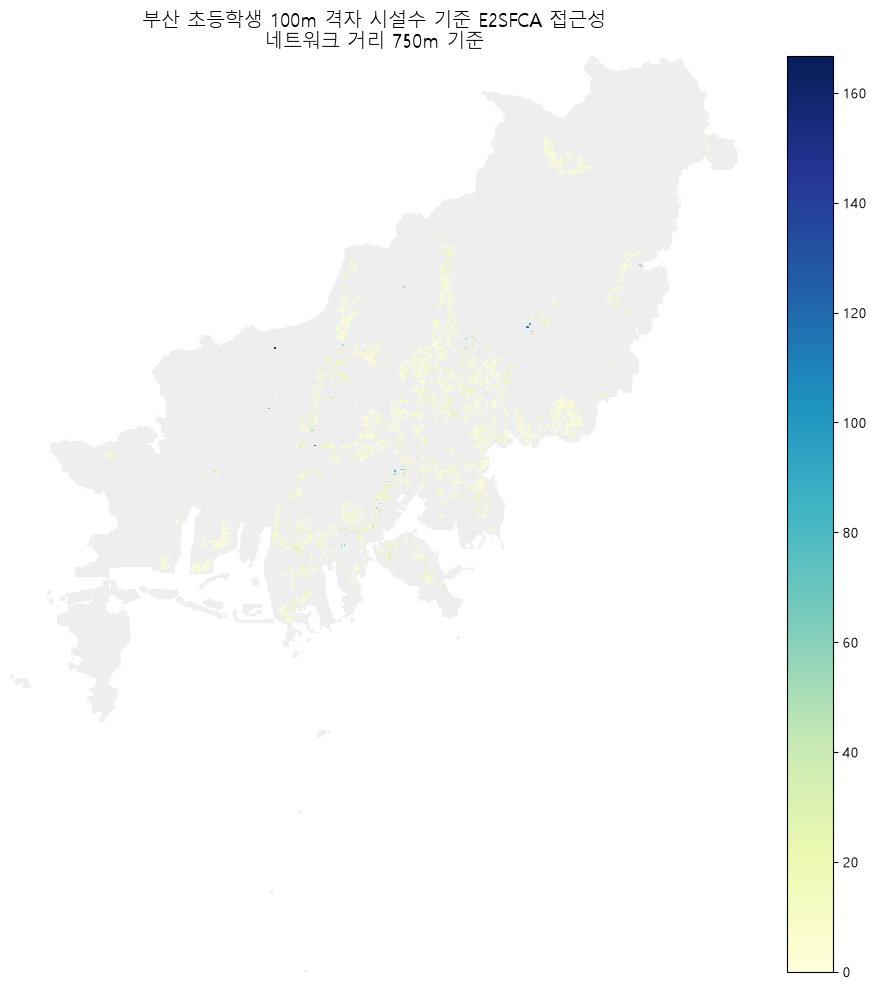

In [22]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column="access_e2sfca_1000",
    cmap="YlGnBu",
    linewidth=0.05,
    edgecolor="#E6E6E6",
    legend=True,
    missing_kwds={
        "color": "#F2F2F2",
        "edgecolor": "#E6E6E6",
        "label": "계산 제외"
    }
)
'''
facility_gdf.plot(
    ax=ax,
    color="#E63946",
    markersize=5,
    marker="o",
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title(
    "부산 초등학생 100m 격자 시설수 기준 E2SFCA 접근성\n네트워크 거리 750m 기준",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
'''
fig.savefig(
    "부산_시설수기준_E2SFCA_접근성지도.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
'''
plt.show()

위의 접근성 지도가 색이 연하고 가독성이 떨어져서

상위 5% 이상 값들은 다 진한 색으로 처리해봄



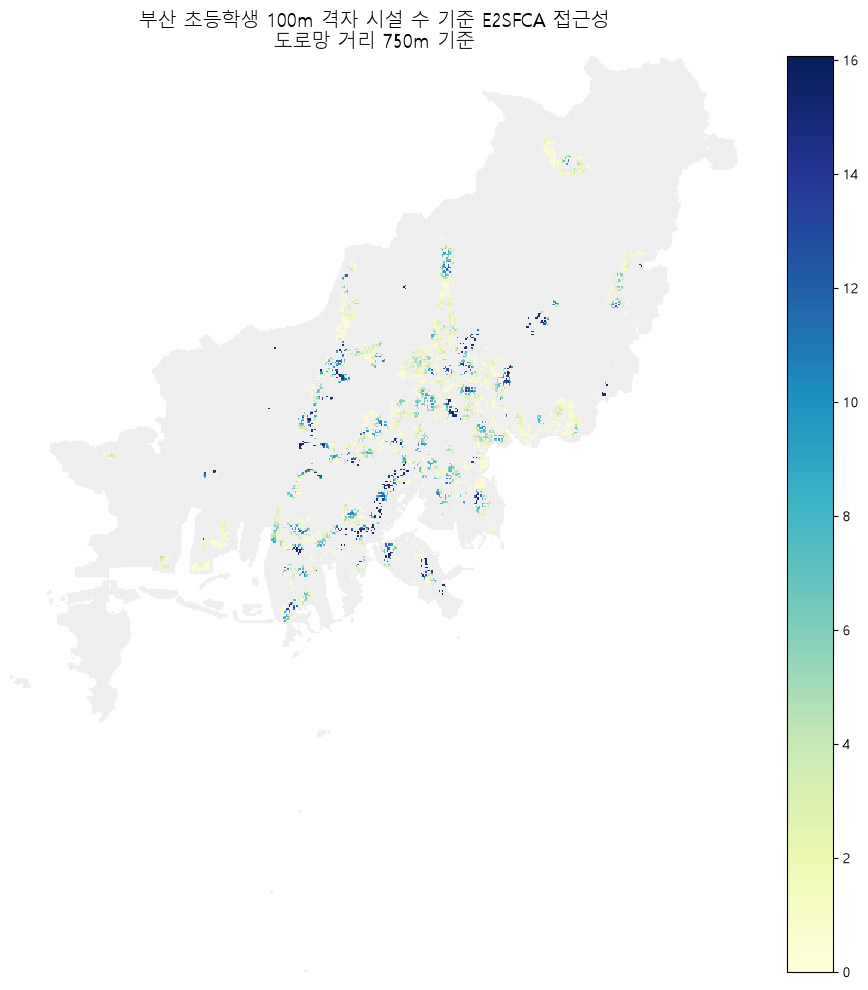

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))

analysis_mask = gdf[pop_col].notna() & (gdf[pop_col] > 0)

# 너무 큰 극단값 때문에 색이 연해지는 걸 막기 위해 95% 분위수를 최대색 기준으로 사용
vmax = gdf.loc[analysis_mask, "access_e2sfca_1000"].quantile(0.95)

gdf.plot(
    ax=ax,
    column="access_e2sfca_1000",
    cmap="YlGnBu",          # YlGnBu보다 더 진하고 직관적
    linewidth=0.03,
    edgecolor="#E6E6E6",
    legend=True,
    vmin=0,
    vmax=vmax,
    missing_kwds={
        "color": "#F2F2F2",
        "edgecolor": "#E6E6E6",
        "label": "초등학생 인구 없음 / 분석 제외"
    }
)
'''
facility_gdf.plot(
    ax=ax,
    color="black",
    markersize=4,
    marker="o",
    alpha=0.7,
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title(
    "부산 초등학생 100m 격자 시설 수 기준 E2SFCA 접근성\n도로망 거리 750m 기준",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
'''
fig.savefig(
    "부산_시설수기준_E2SFCA_접근성지도_진하게.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
'''
plt.show()

## 13.시설부족지역 기준
* 초등학생 인구가 있는 격자만 분석 대상으로 사용
* 고수요 기준: 초등학생 인구 상위 25%
* 저접근성 기준: E2SFCA 접근성 하위 25%

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 초등학생 인구가 있는 격자만 분석 대상으로 사용
analysis_mask = gdf[pop_col].notna() & (gdf[pop_col] > 0)

# 접근성은 이미 11번에서
# 초등학생 인구 있는 격자: 0 또는 양수
# 초등학생 인구 없는 격자: NaN
# 상태로 만들어졌다고 가정

# 분석용 컬럼
gdf["access_for_gap"] = gdf["access_e2sfca_1000"]

# 기준값 계산
pop_q75 = gdf.loc[analysis_mask, pop_col].quantile(0.75)
acc_q25 = gdf.loc[analysis_mask, "access_for_gap"].quantile(0.25)

print("초등학생 인구 상위 25% 기준:", pop_q75)
print("접근성 하위 25% 기준:", acc_q25)

초등학생 인구 상위 25% 기준: 32.0
접근성 하위 25% 기준: 0.0


In [25]:

gdf["high_demand"] = False
gdf["low_access"] = False
gdf["shortage_area"] = False

gdf.loc[analysis_mask, "high_demand"] = gdf.loc[analysis_mask, pop_col] >= pop_q75
gdf.loc[analysis_mask, "low_access"] = gdf.loc[analysis_mask, "access_for_gap"] <= acc_q25

gdf.loc[analysis_mask, "shortage_area"] = (
    gdf.loc[analysis_mask, "high_demand"] &
    gdf.loc[analysis_mask, "low_access"]
)

print("분석 대상 격자 수:", analysis_mask.sum())
print("고수요 격자 수:", gdf["high_demand"].sum())
print("저접근성 격자 수:", gdf["low_access"].sum())
print("부족지역 격자 수:", gdf["shortage_area"].sum())

분석 대상 격자 수: 5539
고수요 격자 수: 1418
저접근성 격자 수: 1631
부족지역 격자 수: 555


In [26]:
gdf["gap_type"] = "분석 제외"

gdf.loc[analysis_mask & gdf["high_demand"] & gdf["low_access"], "gap_type"] = "고수요-저접근성"
gdf.loc[analysis_mask & gdf["high_demand"] & ~gdf["low_access"], "gap_type"] = "고수요-접근성양호"
gdf.loc[analysis_mask & ~gdf["high_demand"] & gdf["low_access"], "gap_type"] = "저수요-저접근성"
gdf.loc[analysis_mask & ~gdf["high_demand"] & ~gdf["low_access"], "gap_type"] = "저수요-접근성양호"

print(gdf["gap_type"].value_counts())

gap_type
분석 제외        76310
저수요-접근성양호     3045
저수요-저접근성      1076
고수요-접근성양호      863
고수요-저접근성       555
Name: count, dtype: int64


## 14.4유형 지도

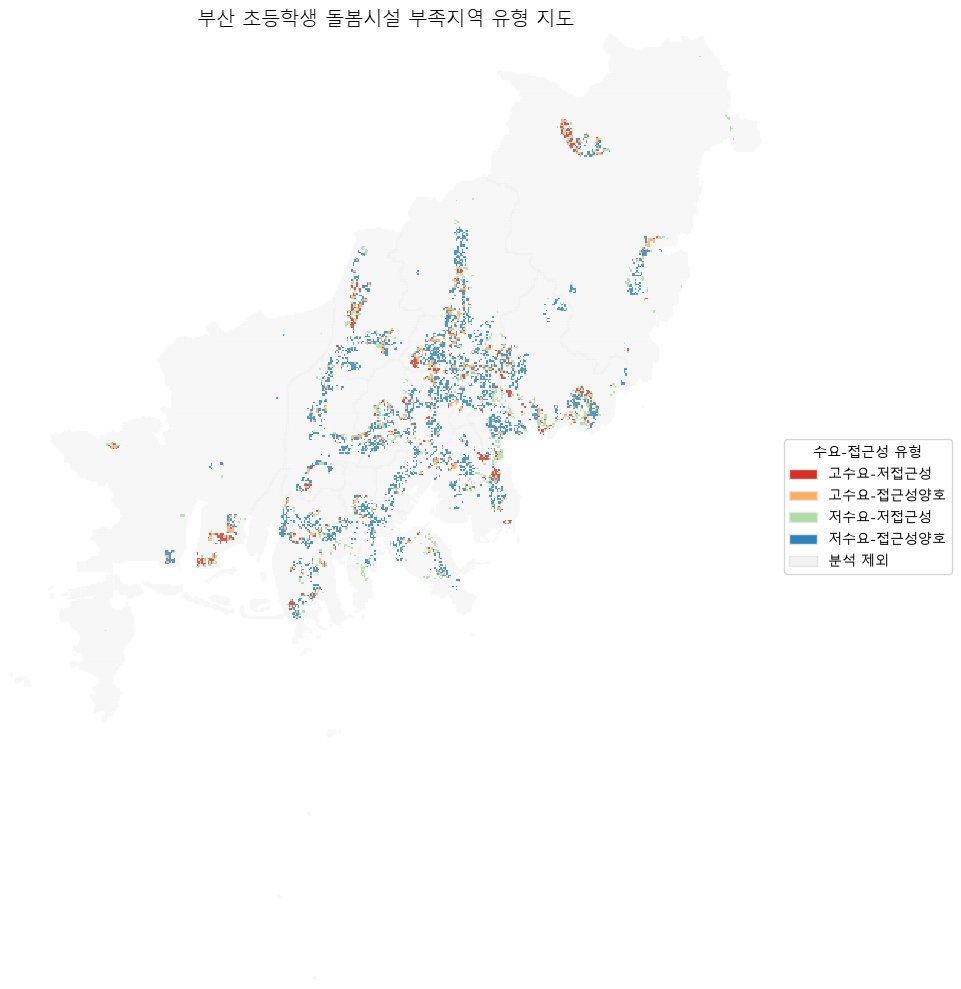

In [27]:
gap_colors = {
    "고수요-저접근성": "#D73027",     # 빨강
    "고수요-접근성양호": "#FDAE61",  # 주황
    "저수요-저접근성": "#ABDDA4",     # 연두
    "저수요-접근성양호": "#2B83BA",  # 파랑
    "분석 제외": "#F2F2F2"           # 회색
}

fig, ax = plt.subplots(figsize=(10, 10))

for typ in ["분석 제외", "저수요-접근성양호", "저수요-저접근성", "고수요-접근성양호", "고수요-저접근성"]:
    subset = gdf[gdf["gap_type"] == typ]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=gap_colors[typ],
            edgecolor="#E6E6E6",
            linewidth=0.03,
            alpha=0.85 if typ != "분석 제외" else 0.35
        )
'''
# 시설 점 보조 표시
facility_gdf.plot(
    ax=ax,
    color="black",
    markersize=4,
    marker="o",
    alpha=0.7,
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

legend_handles = [
    mpatches.Patch(facecolor=gap_colors["고수요-저접근성"], edgecolor="#E6E6E6", label="고수요-저접근성"),
    mpatches.Patch(facecolor=gap_colors["고수요-접근성양호"], edgecolor="#E6E6E6", label="고수요-접근성양호"),
    mpatches.Patch(facecolor=gap_colors["저수요-저접근성"], edgecolor="#E6E6E6", label="저수요-저접근성"),
    mpatches.Patch(facecolor=gap_colors["저수요-접근성양호"], edgecolor="#E6E6E6", label="저수요-접근성양호"),
    mpatches.Patch(facecolor=gap_colors["분석 제외"], edgecolor="#E6E6E6", label="분석 제외")
]

ax.legend(
    handles=legend_handles,
    title="수요-접근성 유형",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_title("부산 초등학생 돌봄시설 부족지역 유형 지도", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
fig.savefig("부산_돌봄시설_부족지역_4유형지도.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 15.고수요-저접근성 강조 지도

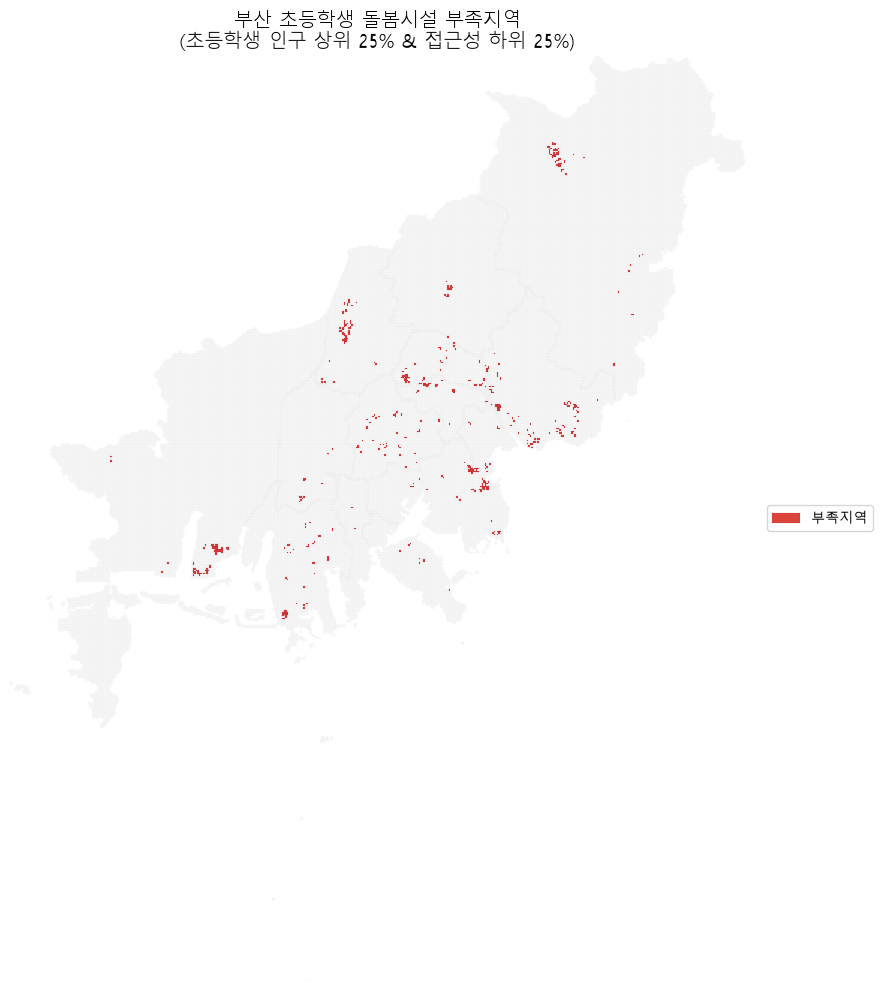

In [28]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    color="#F2F2F2",
    edgecolor="#E6E6E6",
    linewidth=0.03,
    alpha=0.5
)

gdf[gdf["shortage_area"]].plot(
    ax=ax,
    color="#D73027",
    edgecolor="#A50026",
    linewidth=0.08,
    alpha=0.9,
    label="부족지역"
)
'''
# 시설 점
facility_gdf.plot(
    ax=ax,
    color="black",
    markersize=4,
    marker="o",
    alpha=0.7,
    zorder=10,
    label="돌봄 관련 시설"
)
'''
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_title(
    "부산 초등학생 돌봄시설 부족지역\n(초등학생 인구 상위 25% & 접근성 하위 25%)",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
fig.savefig("부산_돌봄시설_부족지역_강조지도.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 여기서부터 소영!! 잘못된 거 없는 지 한번 살펴봐주시길,,,

## 사회 경제적 요인 분석 지도 (토빗 회귀)

## 토빗 분석용 행정동 단위 데이터 만들기

토빗 분석 - 영향요인 분석용이므로 행정동 단위(논문도 행정동 단위로)

| 구분      | 변수                   | 의미         |
| ------- | -------------------- | ---------- |
| 종속변수    | E2SFCA 접근성 점수 | 행정동 평균 접근성 |
| 수요 변수   | 초등학생 인구, 아동 인구 비율    | 돌봄 수요      |
| 사회경제 변수 | 지가, 학원 수(사교육), 기초수급자 수      | 지역 여건      |
| 공급 변수   | 들락날락 수, 돌봄시설 수       | 현재 공급 수준   |


In [29]:
# 행정동 경계 불러오기
dong = gpd.read_file("읍면동/BND_ADM_DONG_PG.shp").to_crs(gdf.crs)

# 격자 중심점 만들기
grid_point = gdf.copy()
grid_point["geometry"] = grid_point.geometry.centroid

# 격자에 행정동 붙이기
grid_dong = gpd.sjoin(
    grid_point,
    dong[["ADM_CD", "ADM_NM", "geometry"]],
    how="left",
    predicate="within"
)

# 행정동별 접근성, 인구 집계
dong_access = (
    grid_dong
    .groupby(["ADM_CD", "ADM_NM"], as_index=False)
    .agg(
        access_mean=("access_e2sfca_1000", "mean"),
        child_pop=(pop_col, "sum"),
        grid_count=(pop_col, "count"),
        shortage_grid=("shortage_area", "sum")
    )
)

dong_access.head()

,ADM_CD,ADM_NM,access_mean,child_pop,grid_count,shortage_grid
0,21010510,중앙동,3.492204,18.0,6,0
1,21010520,동광동,2.304810,21.0,12,0
2,21010530,대청동,20.083552,89.0,19,0
3,21010540,보수동,10.921139,255.0,39,0
4,21010560,부평동,18.705658,36.0,15,0


## 토빗 분석용 변수 전처리 및 최종 데이터 구축

앞에서 계산한 `dong_access`를 기준으로 지가, 학원 수, 기초생활보장 수급자 수를 행정동 단위로 정리한 뒤 최종 분석용 데이터 생성

## 1. 분석 기준 데이터 확인

In [30]:
# 행정동별 접근성 결과 확인
print(dong_access.columns)
dong_access.head()

Index(['ADM_CD', 'ADM_NM', 'access_mean', 'child_pop', 'grid_count',
       'shortage_grid'],
      dtype='str')


,ADM_CD,ADM_NM,access_mean,child_pop,grid_count,shortage_grid
0,21010510,중앙동,3.492204,18.0,6,0
1,21010520,동광동,2.304810,21.0,12,0
2,21010530,대청동,20.083552,89.0,19,0
3,21010540,보수동,10.921139,255.0,39,0
4,21010560,부평동,18.705658,36.0,15,0


## 2. 지가 데이터 정리

In [31]:
# 행정동 및 개별공시지가 shp 불러오기
dong_gdf = gpd.read_file("읍면동/BND_ADM_DONG_PG.shp", encoding="cp949")
land_gdf = gpd.read_file("개별공시지가/AL_D150_26_20260526.shp", encoding="cp949")

# 좌표계 통일
land_gdf = land_gdf.to_crs(dong_gdf.crs)

# 지가 컬럼 숫자형 변환
land_gdf["A9"] = pd.to_numeric(land_gdf["A9"], errors="coerce")

# 지가 필지와 행정동 공간결합
land_joined = gpd.sjoin(
    land_gdf,
    dong_gdf[["ADM_CD", "ADM_NM", "geometry"]],
    how="left",
    predicate="intersects"
)

# 행정동별 지가 요약
land_price = (
    land_joined
    .groupby(["ADM_CD", "ADM_NM"], as_index=False)
    .agg(
        mean_land_price=("A9", "mean"),
        median_land_price=("A9", "median"),
        land_count=("A9", "count")
    )
)

import os
land_price.to_csv("행정동별_지가.csv", index=False, encoding="utf-8-sig")
print("저장 완료:", os.path.exists("행정동별_지가.csv"))
land_price.head()

저장 완료: True


,ADM_CD,ADM_NM,mean_land_price,median_land_price,land_count
0,21010510,중앙동,4.491129e+06,4578000.0,1135
1,21010520,동광동,1.768259e+06,1037000.0,1479
2,21010530,대청동,1.269732e+06,775700.0,2613
3,21010540,보수동,1.084552e+06,671800.0,3719
4,21010560,부평동,5.232802e+06,4002500.0,1858


## 3. 학원 데이터 정리

In [32]:
academy_raw = pd.read_csv(
    "부산광역시교육청 학원 및 교습소 현황_20260615.csv",
    encoding="utf-8-sig",
    low_memory=False
)

# 주소에서 시군구 추출
academy_raw["시군구"] = academy_raw["위치"].str.extract(
    r"부산광역시\s+(\S+(?:구|군))"
)

# 괄호 안의 법정동/읍/면/리 추출
academy_raw["읍면동"] = academy_raw["위치"].str.extract(
    r"\(([가-힣]+(?:읍|면|동\d?가?|동|리))\)"
)

# 같은 학원이 여러 교습과목으로 반복될 수 있으므로 중복 제거
academy_unique = academy_raw.drop_duplicates(
    subset=["학원명", "위치"]
).copy()

academy_unique = academy_unique.dropna(subset=["시군구", "읍면동"]).copy()

academy = (
    academy_unique
    .groupby(["시군구", "읍면동"], as_index=False)
    .agg(academy_count=("학원명", "count"))
)

academy.to_csv("행정동별_학원수.csv", index=False, encoding="utf-8-sig")
academy.head()

,시군구,읍면동,academy_count
0,강서구,명지동,300
1,강서구,송정동,1
2,강서구,신호동,22
3,강서구,지사동,5
4,금정구,구서동,189


## 4. 학원 수를 행정동 접근성 자료에 결합

In [33]:
import pandas as pd
import re

academy_dong_set = set(academy["읍면동"].dropna().unique())

def make_academy_match_name(adm_nm):
    # 행정동명을 학원 주소에서 추출한 법정동명과 최대한 맞추는 함수

    if adm_nm in academy_dong_set:
        return adm_nm

    special_map = {
        "동대신1동": "동대신동1가",
        "동대신2동": "동대신동2가",
        "동대신3동": "동대신동3가",
        "서대신1동": "서대신동1가",
        "서대신2동": "서대신동2가",
        "서대신3동": "서대신동3가",
        "서대신4동": "서대신동4가",
        "중앙동": "중앙동4가",
        "대청동": "대청동4가",
        "보수동": "보수동1가",
        "부평동": "부평동1가",
        "남포동": "남포동6가",
        "영선1동": "영선동1가",
        "영선2동": "영선동2가",
        "봉래1동": "봉래동3가",
        "봉래2동": "봉래동4가",
    }

    if adm_nm in special_map:
        return special_map[adm_nm]

    # 예: 화명1동 → 화명동, 광안4동 → 광안동
    candidate = re.sub(r"(.+?)\d+동$", r"\1동", adm_nm)

    if candidate in academy_dong_set:
        return candidate

    return adm_nm


dong_access["academy_match_dong"] = dong_access["ADM_NM"].apply(make_academy_match_name)

model_df = dong_access.merge(
    academy[["읍면동", "academy_count"]],
    left_on="academy_match_dong",
    right_on="읍면동",
    how="left"
)

model_df["academy_count"] = model_df["academy_count"].fillna(0)

model_df[["ADM_CD", "ADM_NM", "academy_match_dong", "academy_count"]].head()

,ADM_CD,ADM_NM,academy_match_dong,academy_count
0,21010510,중앙동,중앙동4가,6.0
1,21010520,동광동,동광동,0.0
2,21010530,대청동,대청동4가,5.0
3,21010540,보수동,보수동1가,4.0
4,21010560,부평동,부평동1가,1.0


## 5. 부산 행정동만 남기기

In [34]:
model_df["ADM_CD"] = model_df["ADM_CD"].astype(str)

model_df_busan = model_df[
    model_df["ADM_CD"].str.startswith("21")
].copy()

print("부산 행정동 수:", len(model_df_busan))
print("학원 수 0인 행정동 수:", (model_df_busan["academy_count"] == 0).sum())


부산 행정동 수: 207
학원 수 0인 행정동 수: 20


## 6. 기초생활보장 수급자 데이터 정리

In [35]:
welfare_raw = pd.read_csv(
    "부산광역시_기초생활보장 수급자 읍면동 현황_20231231.csv",
    encoding="cp949"
)

# 2023년 자료만 사용
welfare_2023 = welfare_raw[welfare_raw["연도"] == 2023].copy()

# 구 전체 합계 행 제거
welfare_2023 = welfare_2023[
    welfare_2023["시군구"] != welfare_2023["읍면동"]
].copy()

# 명칭 변경 반영
welfare_2023["읍면동"] = welfare_2023["읍면동"].replace({
    "일광면": "일광읍"
})

welfare_cols = [
    "일반수급자 수급권자수",
    "조건부수급자 수급권자수",
    "특례수급자 수급권자수",
    "기타 수급권자수",
    "시설수급자 수급권자수"
]

for col in welfare_cols:
    welfare_2023[col] = pd.to_numeric(welfare_2023[col], errors="coerce").fillna(0)

welfare_2023["welfare_count"] = welfare_2023[welfare_cols].sum(axis=1)

welfare = welfare_2023[["시군구", "읍면동", "welfare_count"]].copy()
welfare.to_csv("행정동별_기초수급자수.csv", index=False, encoding="utf-8-sig")

welfare.head()

,시군구,읍면동,welfare_count
446,중구,중앙동,182
447,중구,동광동,464
448,중구,대청동,714
449,중구,보수동,1209
450,중구,부평동,543


## 7. 기초수급자 데이터에 행정동 코드 붙이기

In [36]:
dong_code_table = dong_access[["ADM_CD", "ADM_NM"]].copy()
dong_code_table = dong_code_table.rename(columns={"ADM_NM": "읍면동"})
dong_code_table["ADM_CD"] = dong_code_table["ADM_CD"].astype(str)

welfare_with_code = welfare.merge(
    dong_code_table,
    on="읍면동",
    how="left"
)

print("ADM_CD 안 붙은 기초수급자 행 수:", welfare_with_code["ADM_CD"].isna().sum())

welfare_with_code.to_csv(
    "행정동별_기초수급자수_ADM_CD포함.csv",
    index=False,
    encoding="utf-8-sig"
)

welfare_with_code.head()


ADM_CD 안 붙은 기초수급자 행 수: 0


,시군구,읍면동,welfare_count,ADM_CD
0,중구,중앙동,182,21010510
1,중구,동광동,464,21010520
2,중구,대청동,714,21010530
3,중구,보수동,1209,21010540
4,중구,부평동,543,21010560


## 8. 최종 데이터 결합

In [37]:
import os
import pandas as pd

# 지가 데이터 불러오기
land_price = pd.read_csv("행정동별_지가.csv", encoding="utf-8-sig")

# ADM_CD 자료형 통일
model_df_busan["ADM_CD"] = model_df_busan["ADM_CD"].astype(str)
land_price["ADM_CD"] = land_price["ADM_CD"].astype(str)
welfare_with_code["ADM_CD"] = welfare_with_code["ADM_CD"].astype(str)

# 지가 데이터 결합
model_df_final = model_df_busan.merge(
    land_price[["ADM_CD", "mean_land_price", "median_land_price", "land_count"]],
    on="ADM_CD",
    how="left"
)

# 기초수급자 데이터 결합
model_df_final = model_df_final.merge(
    welfare_with_code[["ADM_CD", "welfare_count"]],
    on="ADM_CD",
    how="left"
)

# 결측값 확인
check_cols = [
    "access_mean",
    "child_pop",
    "shortage_grid",
    "academy_count",
    "welfare_count",
    "mean_land_price",
    "median_land_price",
    "land_count"
]

print("정리 전 결측값:")
print(model_df_final[check_cols].isna().sum())

# 아동 인구가 있고, 주요 변수에 결측이 없는 행정동만 남기기
model_df_final_clean = model_df_final[
    (model_df_final["child_pop"] > 0) &
    (model_df_final["access_mean"].notna()) &
    (model_df_final["welfare_count"].notna()) &
    (model_df_final["mean_land_price"].notna()) &
    (model_df_final["academy_count"].notna())
].copy()

print("\n정리 후 결측값:")
print(model_df_final_clean[check_cols].isna().sum())

# 토빗 분석용 최종 데이터 저장
model_df_final_clean.to_csv(
    "토빗분석용_행정동별_최종데이터_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n최종 행 수:", len(model_df_final_clean))
print("저장 완료:", os.path.exists("토빗분석용_행정동별_최종데이터_clean.csv"))

model_df_final_clean.head()

정리 전 결측값:
access_mean          3
child_pop            0
shortage_grid        0
academy_count        0
welfare_count        1
mean_land_price      0
median_land_price    0
land_count           0
dtype: int64

정리 후 결측값:
access_mean          0
child_pop            0
shortage_grid        0
academy_count        0
welfare_count        0
mean_land_price      0
median_land_price    0
land_count           0
dtype: int64

최종 행 수: 204
저장 완료: True


,ADM_CD,ADM_NM,access_mean,child_pop,grid_count,shortage_grid,academy_match_dong,읍면동,academy_count,mean_land_price,median_land_price,land_count,welfare_count
0,21010510,중앙동,3.492204,18.0,6,0,중앙동4가,중앙동4가,6.0,4.491129e+06,4578000.0,1135,182.0
1,21010520,동광동,2.304810,21.0,12,0,동광동,NaN,0.0,1.768259e+06,1037000.0,1479,464.0
2,21010530,대청동,20.083552,89.0,19,0,대청동4가,대청동4가,5.0,1.269732e+06,775700.0,2613,714.0
3,21010540,보수동,10.921139,255.0,39,0,보수동1가,보수동1가,4.0,1.084552e+06,671800.0,3719,1209.0
4,21010560,부평동,18.705658,36.0,15,0,부평동1가,부평동1가,1.0,5.232802e+06,4002500.0,1858,543.0


## 토빗 분석 모형 정의

종속변수인 돌봄공백 격자 수(`shortage_grid`)는 0 이상의 값만 가지므로, 0에서 좌측 검열된 토빗 모형을 사용한다.

shortage_grid = f(아동인구, 학원 수, 기초수급자 수, 평균지가)

In [38]:
!pip install statsmodels

In [39]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import norm

class TobitModel(GenericLikelihoodModel):
    def __init__(self, endog, exog, left=0, right=np.inf, **kwds):
        self.left = left
        self.right = right
        super().__init__(endog, exog, **kwds)

    def nloglikeobs(self, params):
        beta = params[:-1]
        sigma = np.exp(params[-1])

        y = self.endog
        Xb = np.dot(self.exog, beta)

        left = self.left

        # y > left: 일반 관측값
        uncensored = y > left

        ll = np.zeros(len(y))

        # 비검열 관측치 likelihood
        ll[uncensored] = norm.logpdf(
            y[uncensored],
            loc=Xb[uncensored],
            scale=sigma
        )

        # left-censored 관측치 likelihood
        ll[~uncensored] = norm.logcdf(
            (left - Xb[~uncensored]) / sigma
        )

        return -ll

    def fit(self, start_params=None, maxiter=10000, maxfun=5000, **kwds):
        if start_params is None:
            ols_res = sm.OLS(self.endog, self.exog).fit()
            sigma_start = np.log(np.std(ols_res.resid))
            start_params = np.append(ols_res.params, sigma_start)

        return super().fit(
            start_params=start_params,
            maxiter=maxiter,
            maxfun=maxfun,
            **kwds
        )

In [ ]:
# 토빗 분석용 데이터 생성
tobit_df = model_df_final_clean.copy()

# 분석에 사용할 변수만 선택
tobit_cols = [
    "shortage_grid",
    "child_pop",
    "mean_land_price",
    "academy_count",
    "welfare_count"
]

tobit_df = tobit_df[tobit_cols].copy()

# 숫자형 변환
for col in tobit_cols:
    tobit_df[col] = pd.to_numeric(tobit_df[col], errors="coerce")

# 결측 제거
tobit_df = tobit_df.dropna().copy()

# shortage_grid는 0 이상만 사용
tobit_df = tobit_df[tobit_df["shortage_grid"] >= 0].copy()

# 로그 변환
tobit_df["ln_child_pop"] = np.log1p(tobit_df["child_pop"])
tobit_df["ln_land_price"] = np.log1p(tobit_df["mean_land_price"])
tobit_df["ln_academy"] = np.log1p(tobit_df["academy_count"])
tobit_df["ln_welfare"] = np.log1p(tobit_df["welfare_count"])

# 종속변수
y = tobit_df["shortage_grid"].values

# 독립변수
X = tobit_df[[
    "ln_child_pop",
    "ln_land_price",
    "ln_academy",
    "ln_welfare"
]]

# 상수항 추가
X = sm.add_constant(X)

# 토빗 모형 추정
tobit_model = TobitModel(y, X, left=0)
tobit_result = tobit_model.fit()

print(tobit_result.summary())

Optimization terminated successfully.
         Current function value: 1.720239
         Iterations: 556
         Function evaluations: 873
                              TobitModel Results                              
Dep. Variable:                      y   Log-Likelihood:                -350.93
Model:                     TobitModel   AIC:                             713.9
Method:            Maximum Likelihood   BIC:                             733.8
Date:                Tue, 07 Jul 2026                                         
Time:                        22:46:54                                         
No. Observations:                 204                                         
Df Residuals:                     199                                         
Df Model:                           4                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

c:\Users\beave\anaconda3\envs\geo\Lib\site-packages\statsmodels\base\model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warnings.warn("df_model + k_constant + k_extra "
c:\Users\beave\anaconda3\envs\geo\Lib\site-packages\statsmodels\base\model.py:2752: UserWarning: df_resid differs from nobs - k_params
  warnings.warn("df_resid differs from nobs - k_params")


## 토빗 분석 결과 해석 기준

본 분석에서는 고수요·저접근 격자 수(`shortage_grid`)를 종속변수로 설정하였다.  
따라서 계수가 양수이면 해당 변수가 증가할수록 돌봄공백 격자 수가 증가하는 경향을 의미하고, 계수가 음수이면 돌봄공백 격자 수가 감소하는 경향을 의미한다.

(p_value < 0.05이면 통계적으로 유의)

| 변수 | 계수 방향 | 해석 |
|---|---:|---|
| `ln_child_pop` | 양수 | 아동 인구가 많은 지역일수록 돌봄 수요가 커져 돌봄공백 격자 수가 증가하는 경향 |
| `ln_child_pop` | 음수 | 아동 인구가 많은 지역에 시설 공급도 함께 배치되어 돌봄공백이 줄어드는 경향 |
| `ln_land_price` | 양수 | 지가가 높은 지역일수록 시설 입지가 제한되어 돌봄공백이 커지는 경향 |
| `ln_land_price` | 음수 | 지가가 높은 중심지일수록 기존 생활 인프라가 많아 돌봄공백이 줄어드는 경향 |
| `ln_academy` | 양수 | 학원 수가 많은 지역에도 공공 돌봄시설 공급이 충분하지 않아 돌봄공백이 커지는 경향 |
| `ln_academy` | 음수 | 사교육 인프라가 많은 지역일수록 아동 관련 시설 접근성도 좋아 돌봄공백이 줄어드는 경향 |
| `ln_welfare` | 양수 | 기초수급자 수가 많은 취약지역일수록 돌봄공백이 커지는 경향 |
| `ln_welfare` | 음수 | 취약계층이 많은 지역에 공공 돌봄서비스가 우선 배치되어 돌봄공백이 줄어드는 경향 |

## 사회경제적 요인별 공간 분포 지도

토빗 분석에 사용한 사회경제적 요인인 학원 수, 기초생활보장 수급자 수, 평균 지가를 행정동 단위 단계구분도로 시각화 → 돌봄공백 지역이 어떤 사회경제적 특성을 가진 지역과 중첩되는지 확인

In [40]:
# ADM_CD 자료형 통일
dong_gdf["ADM_CD"] = dong_gdf["ADM_CD"].astype(str)
model_df_final_clean["ADM_CD"] = model_df_final_clean["ADM_CD"].astype(str)

# 지도용 GeoDataFrame 생성
map_gdf = dong_gdf.merge(
    model_df_final_clean,
    on=["ADM_CD", "ADM_NM"],
    how="left"
)

map_gdf.head()

,BASE_DATE,ADM_CD,ADM_NM,geometry,access_mean,child_pop,grid_count,shortage_grid,academy_match_dong,읍면동,academy_count,mean_land_price,median_land_price,land_count,welfare_count
0,20250630,11010530,사직동,"POLYGON ((197702.069 553187.311, 197703.431 55...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20250630,11010540,삼청동,"POLYGON ((197980.839 555346.068, 197995.421 55...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20250630,11010550,부암동,"POLYGON ((196621.023 556395.88, 196628.324 556...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20250630,11010560,평창동,"POLYGON ((197800.72 559064.245, 197782.581 558...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20250630,11010570,무악동,"POLYGON ((196444.745 553384.564, 196471.618 55...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. 행정동별 학원 수 지도

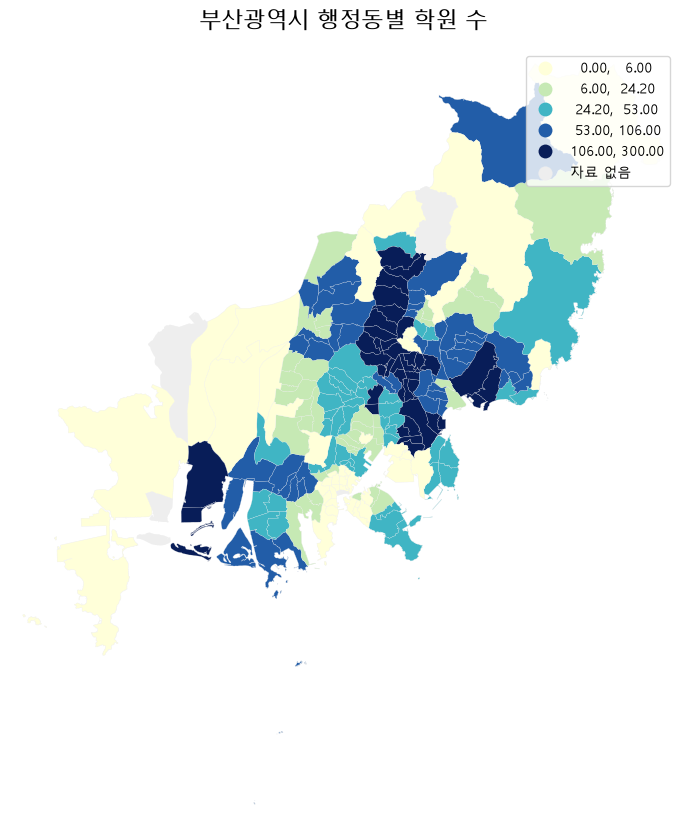

In [41]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 부산 행정동만 선택
dong_gdf["ADM_CD"] = dong_gdf["ADM_CD"].astype(str)
model_df_final_clean["ADM_CD"] = model_df_final_clean["ADM_CD"].astype(str)

busan_dong_gdf = dong_gdf[dong_gdf["ADM_CD"].str.startswith("21")].copy()
busan_df = model_df_final_clean[
    model_df_final_clean["ADM_CD"].str.startswith("21")
].copy()

# 지도용 데이터 결합
busan_map_gdf = busan_dong_gdf.merge(
    busan_df,
    on=["ADM_CD", "ADM_NM"],
    how="left"
)

# 지도 그리기
fig, ax = plt.subplots(figsize=(9, 10))

# 부산 지형 배경
busan_map_gdf.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="#f5f5f5",
    linewidth=0.2
)

# 학원 수 단계구분도
busan_map_gdf.plot(
    column="academy_count",
    cmap="YlGnBu",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="#f2f2f2",
    linewidth=0.15,
    ax=ax,
    missing_kwds={
        "color": "#eeeeee",
        "label": "자료 없음"
    }
)

# 부산 지형만 딱 보이도록 범위 설정
minx, miny, maxx, maxy = busan_map_gdf.total_bounds

x_margin = (maxx - minx) * 0.02
y_margin = (maxy - miny) * 0.02

ax.set_xlim(minx - x_margin, maxx + x_margin)
ax.set_ylim(miny - y_margin, maxy + y_margin)

ax.set_title("부산광역시 행정동별 학원 수", fontsize=16, pad=15)
ax.set_axis_off()
ax.set_aspect("equal")

plt.savefig(
    "부산광역시_행정동별_학원수_지도.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2. 행정동별 기초수급자 수 지도

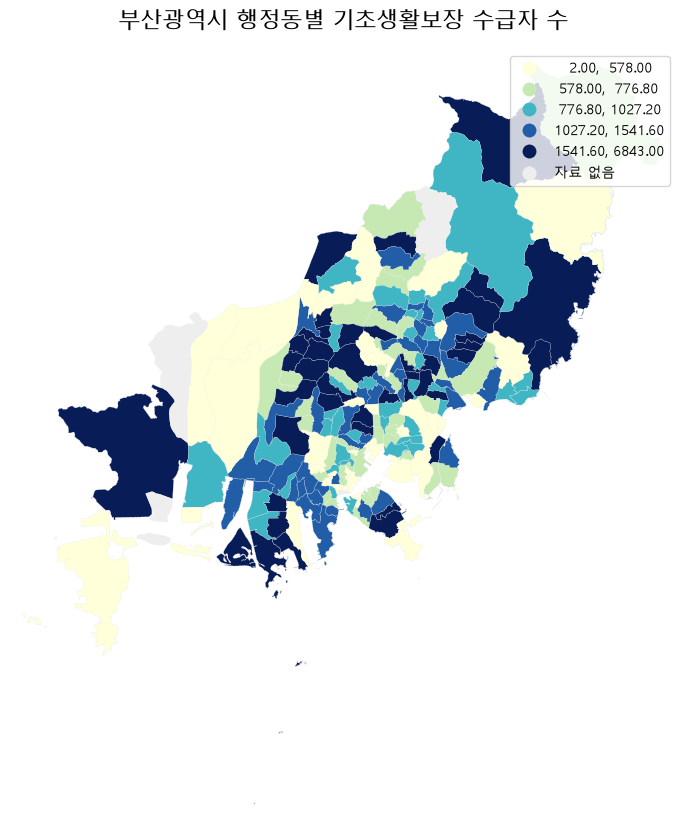

In [42]:
fig, ax = plt.subplots(figsize=(9, 10))

busan_map_gdf.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="#f5f5f5",
    linewidth=0.2
)

busan_map_gdf.plot(
    column="welfare_count",
    cmap="YlGnBu",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="#f2f2f2",
    linewidth=0.15,
    ax=ax,
    missing_kwds={
        "color": "#eeeeee",
        "label": "자료 없음"
    }
)

minx, miny, maxx, maxy = busan_map_gdf.total_bounds
x_margin = (maxx - minx) * 0.02
y_margin = (maxy - miny) * 0.02

ax.set_xlim(minx - x_margin, maxx + x_margin)
ax.set_ylim(miny - y_margin, maxy + y_margin)

ax.set_title("부산광역시 행정동별 기초생활보장 수급자 수", fontsize=16, pad=15)
ax.set_axis_off()
ax.set_aspect("equal")

plt.savefig(
    "부산광역시_행정동별_기초수급자수_지도.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. 행정동별 평균 지가 지도

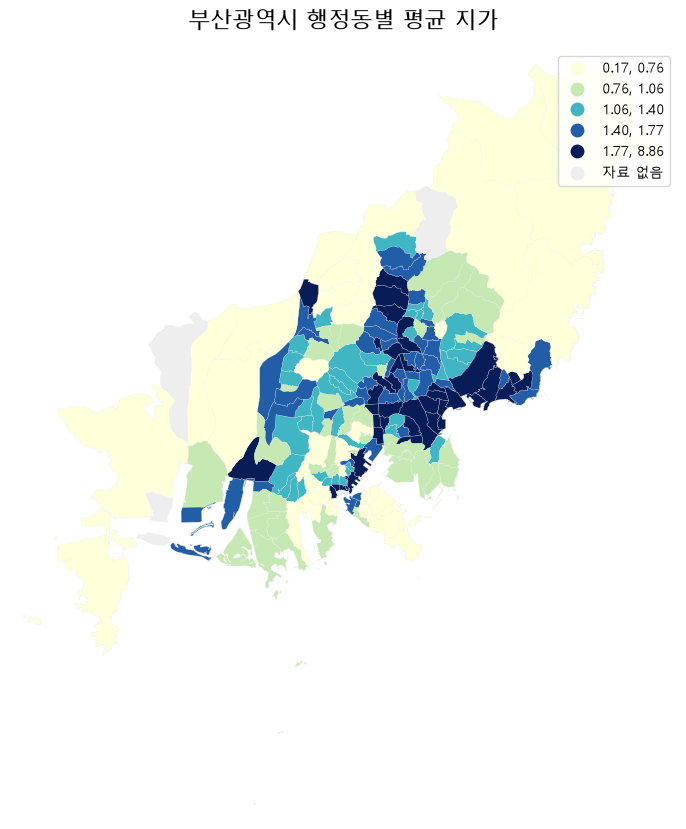

In [43]:
busan_map_gdf["mean_land_price_million"] = (
    busan_map_gdf["mean_land_price"] / 1_000_000
)

fig, ax = plt.subplots(figsize=(9, 10))

busan_map_gdf.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="#f5f5f5",
    linewidth=0.2
)

busan_map_gdf.plot(
    column="mean_land_price_million",
    cmap="YlGnBu",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="#f2f2f2",
    linewidth=0.15,
    ax=ax,
    missing_kwds={
        "color": "#eeeeee",
        "label": "자료 없음"
    }
)

minx, miny, maxx, maxy = busan_map_gdf.total_bounds
x_margin = (maxx - minx) * 0.02
y_margin = (maxy - miny) * 0.02

ax.set_xlim(minx - x_margin, maxx + x_margin)
ax.set_ylim(miny - y_margin, maxy + y_margin)

ax.set_title("부산광역시 행정동별 평균 지가", fontsize=16, pad=15)
ax.set_axis_off()
ax.set_aspect("equal")

plt.savefig(
    "부산광역시_행정동별_평균지가_지도.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. 사회경제적 취약성 보조지도

## 1. 사회경제적 취약성 점수 만들기

In [44]:
from sklearn.preprocessing import MinMaxScaler

# 사회경제적 취약성 점수에 사용할 변수
vul_cols = [
    "welfare_count",    # 기초수급자 수: 많을수록 취약
    "shortage_grid",    # 돌봄공백 격자 수: 많을수록 취약
    "academy_count"     # 학원 수: 적을수록 취약
]

vul_df = model_df_final_clean[vul_cols].copy()

# 숫자형 변환
for col in vul_cols:
    vul_df[col] = pd.to_numeric(vul_df[col], errors="coerce")

# 결측 제거 또는 0 처리
vul_df = vul_df.fillna(0)

# 0~1 사이로 표준화
scaler = MinMaxScaler()
scaled = scaler.fit_transform(vul_df)

model_df_final_clean["welfare_s"] = scaled[:, 0]
model_df_final_clean["shortage_s"] = scaled[:, 1]
model_df_final_clean["academy_s"] = scaled[:, 2]

# 사회경제적 취약성 점수
# 기초수급자 많음 + 돌봄공백 많음 + 학원 수 적음
model_df_final_clean["socio_vulnerability"] = (
    model_df_final_clean["welfare_s"] +
    model_df_final_clean["shortage_s"] +
    (1 - model_df_final_clean["academy_s"])
)

model_df_final_clean[[
    "ADM_CD",
    "ADM_NM",
    "welfare_count",
    "shortage_grid",
    "academy_count",
    "socio_vulnerability"
]].sort_values("socio_vulnerability", ascending=False).head(10)

# 지도용 데이터 만들기
# ADM_CD 문자형 통일
dong_gdf["ADM_CD"] = dong_gdf["ADM_CD"].astype(str)
model_df_final_clean["ADM_CD"] = model_df_final_clean["ADM_CD"].astype(str)

# 지도용 데이터 생성
map_gdf = dong_gdf.merge(
    model_df_final_clean,
    on=["ADM_CD", "ADM_NM"],
    how="left"
)

map_gdf.head()

,BASE_DATE,ADM_CD,ADM_NM,geometry,access_mean,child_pop,grid_count,shortage_grid,academy_match_dong,읍면동,academy_count,mean_land_price,median_land_price,land_count,welfare_count,welfare_s,shortage_s,academy_s,socio_vulnerability
0,20250630,11010530,사직동,"POLYGON ((197702.069 553187.311, 197703.431 55...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20250630,11010540,삼청동,"POLYGON ((197980.839 555346.068, 197995.421 55...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20250630,11010550,부암동,"POLYGON ((196621.023 556395.88, 196628.324 556...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20250630,11010560,평창동,"POLYGON ((197800.72 559064.245, 197782.581 558...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20250630,11010570,무악동,"POLYGON ((196444.745 553384.564, 196471.618 55...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. 사회경제적 취약성 보조지도 그리기

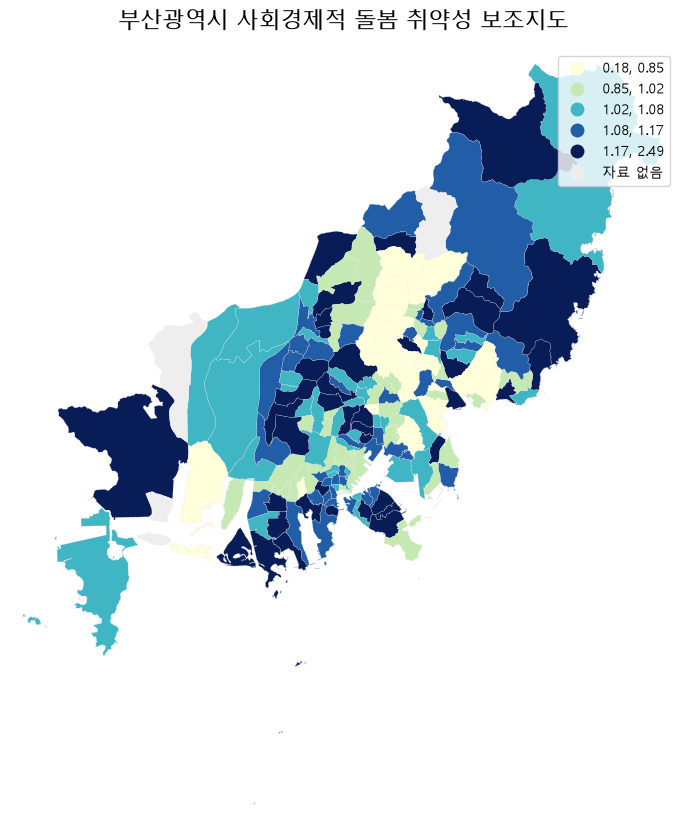

In [45]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ADM_CD 문자형 통일
map_gdf["ADM_CD"] = map_gdf["ADM_CD"].astype(str)

# 부산광역시 행정동만 선택
busan_map_gdf = map_gdf[map_gdf["ADM_CD"].str.startswith("21")].copy()

fig, ax = plt.subplots(figsize=(9, 10))

# 부산 지형 배경
busan_map_gdf.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="#f5f5f5",
    linewidth=0.2
)

# 사회경제적 취약성 지도
busan_map_gdf.plot(
    column="socio_vulnerability",
    cmap="YlGnBu",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="#f2f2f2",
    linewidth=0.15,
    ax=ax,
    missing_kwds={
        "color": "#eeeeee",
        "label": "자료 없음"
    }
)

# 부산 지형만 딱 보이도록 범위 설정
minx, miny, maxx, maxy = busan_map_gdf.total_bounds
x_margin = (maxx - minx) * 0.02
y_margin = (maxy - miny) * 0.02

ax.set_xlim(minx - x_margin, maxx + x_margin)
ax.set_ylim(miny - y_margin, maxy + y_margin)

ax.set_title("부산광역시 사회경제적 돌봄 취약성 보조지도", fontsize=16, pad=15)
ax.set_axis_off()
ax.set_aspect("equal")

plt.savefig(
    "부산광역시_사회경제적_돌봄취약성_보조지도.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. 상위 25% 취약지역 지도

상위 25% 기준값: 1.1361306826487354
상위 25% 행정동 수: 51


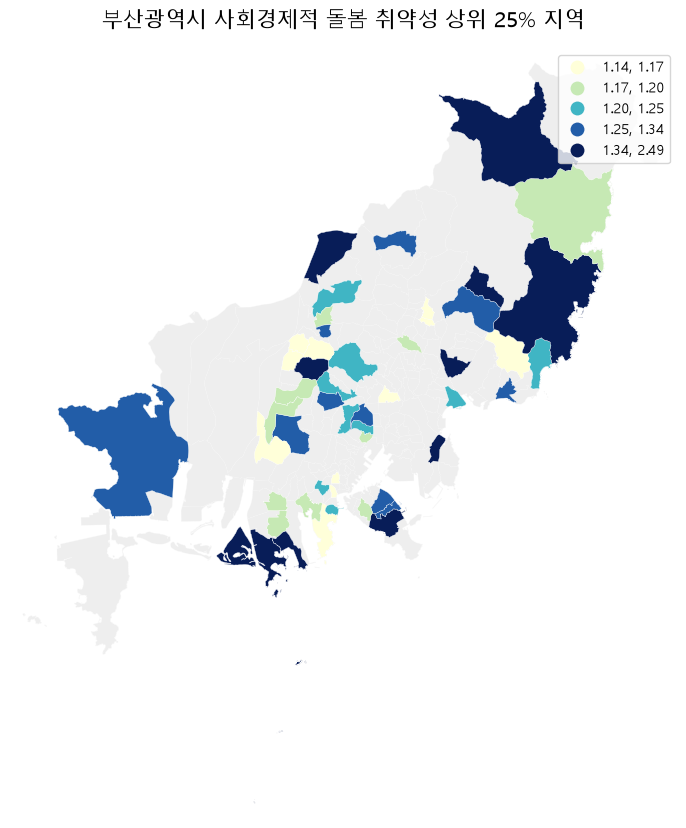

In [46]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 부산 행정동만 사용
busan_map_gdf["ADM_CD"] = busan_map_gdf["ADM_CD"].astype(str)

# 사회경제적 취약성 상위 25% 기준값 계산
threshold_75 = busan_map_gdf["socio_vulnerability"].quantile(0.75)

# 상위 25% 여부 표시
busan_map_gdf["is_top25_vul"] = (
    busan_map_gdf["socio_vulnerability"] >= threshold_75
)

print("상위 25% 기준값:", threshold_75)
print("상위 25% 행정동 수:", busan_map_gdf["is_top25_vul"].sum())

# 상위 25% 데이터만 따로 분리
top25_gdf = busan_map_gdf[busan_map_gdf["is_top25_vul"]].copy()

# 지도 그리기
fig, ax = plt.subplots(figsize=(9, 10))

# 1. 전체 부산 행정동은 연회색으로 표시
busan_map_gdf.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="#f7f7f7",
    linewidth=0.2
)

# 2. 상위 25% 취약지역만 색으로 표시
top25_gdf.plot(
    column="socio_vulnerability",
    cmap="YlGnBu",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.25,
    ax=ax
)

# 부산 범위에 맞게 축 조정
minx, miny, maxx, maxy = busan_map_gdf.total_bounds
x_margin = (maxx - minx) * 0.02
y_margin = (maxy - miny) * 0.02

ax.set_xlim(minx - x_margin, maxx + x_margin)
ax.set_ylim(miny - y_margin, maxy + y_margin)

ax.set_title("부산광역시 사회경제적 돌봄 취약성 상위 25% 지역", fontsize=15, pad=15)
ax.set_axis_off()
ax.set_aspect("equal")

plt.savefig(
    "부산광역시_사회경제적_돌봄취약성_상위25퍼센트_지도.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 고수요 - 저접근 지역 안에서 위성형 후보지 찾기

## 1. 기존 데이터 확인 및 정리

In [47]:
import pandas as pd
import geopandas as gpd

# 후보시설 불러오기
library_df = pd.read_csv("부산_도서관_좌표.csv", encoding="utf-8-sig")
admin_df = pd.read_csv("부산_행정복지센터_API.csv", encoding="utf-8-sig")

# 컬럼 확인
print("도서관 컬럼:", library_df.columns)
print("행정복지센터 컬럼:", admin_df.columns)

도서관 컬럼: Index(['name', 'candidate_type', 'city', 'gugun', 'category', 'address', 'lat',
       'lng', 'tel', 'closed_day', 'week_start', 'week_end', 'sat_start',
       'sat_end', 'holiday_start', 'holiday_end', 'seat', 'books',
       'publications', 'nonbook', 'loan_num', 'loan_day', 'organization',
       'site_area', 'build_area', 'homepage', 'data_date', 'inst_code',
       'inst_name'],
      dtype='str')
행정복지센터 컬럼: Index(['dept', 'addrRoad', 'tel', 'gugun', 'dataDay', 'posCd', 'lat', 'lng'], dtype='str')


In [48]:
# 1. 도서관 데이터 정리
library_df["lat"] = pd.to_numeric(library_df["lat"], errors="coerce")
library_df["lng"] = pd.to_numeric(library_df["lng"], errors="coerce")

library_df = library_df.dropna(subset=["name", "lat", "lng"]).copy()

library_gdf = gpd.GeoDataFrame(
    library_df,
    geometry=gpd.points_from_xy(library_df["lng"], library_df["lat"]),
    crs="EPSG:4326"
)

library_gdf["candidate_type"] = "도서관"
library_gdf["address"] = library_gdf["address"]

In [49]:
# 2. 행정복지센터 데이터 정리
admin_df["lat"] = pd.to_numeric(admin_df["lat"], errors="coerce")
admin_df["lng"] = pd.to_numeric(admin_df["lng"], errors="coerce")

admin_df = admin_df.dropna(subset=["dept", "lat", "lng"]).copy()

# 컬럼명 통일
admin_df = admin_df.rename(columns={
    "dept": "name",
    "addrRoad": "address"
})

admin_gdf = gpd.GeoDataFrame(
    admin_df,
    geometry=gpd.points_from_xy(admin_df["lng"], admin_df["lat"]),
    crs="EPSG:4326"
)

admin_gdf["candidate_type"] = "행정복지센터"

In [50]:
# 3. 기존 분석 격자 gdf 좌표계에 맞추기
library_gdf = library_gdf.to_crs(gdf.crs)
admin_gdf = admin_gdf.to_crs(gdf.crs)

In [51]:
# 4. 도서관 + 행정복지센터 후보시설 합치기
candidate_gdf = pd.concat([
    library_gdf[["name", "candidate_type", "gugun", "address", "geometry"]],
    admin_gdf[["name", "candidate_type", "gugun", "address", "geometry"]]
], ignore_index=True)

candidate_gdf = gpd.GeoDataFrame(
    candidate_gdf,
    geometry="geometry",
    crs=gdf.crs
)

print(candidate_gdf.shape)
candidate_gdf.head()

(350, 5)


,name,candidate_type,gugun,address,geometry
0,유엔평화기념관 작은도서관,도서관,남구,"부산광역시 남구 홍곡로320번길 106, (대연동) 유엔기념관 3층",POINT (1145169.968 1682224.228)
1,작은나무 큰숲도서관,도서관,남구,부산광역시 남구 용호로159번길 10(용호동),POINT (1146908.359 1681477.238)
2,작은나무숲,도서관,남구,부산광역시 남구 양지골로 141(감만동),POINT (1144536.415 1681136.556)
3,문현마을문고,도서관,남구,부산광역시 남구 수영로39번길 35(문현동),POINT (1143228.592 1683726.043)
4,부산광역시남구도서관,도서관,남구,부산광역시 남구 수영로 267번길 61(대연동),POINT (1145269.096 1683661.818)


## 2. 고수요 - 저접근성 지역 추출 및 수요 계산

In [52]:
# 5. 고수요-저접근성 지역만 추출
shortage_gdf = gdf[gdf["gap_type"] == "고수요-저접근성"].copy()

# 격자 중심점으로 계산
shortage_point = shortage_gdf.copy()
shortage_point["geometry"] = shortage_point.geometry.centroid

In [53]:
# 6. 후보지별 750m 이내 고수요-저접근 수요 계산
pop_col = "val"
BUFFER_DIST = 750

candidate_gdf["candidate_id"] = range(len(candidate_gdf))

coverage_list = []

for idx, cand in candidate_gdf.iterrows():
    buffer_geom = cand.geometry.buffer(BUFFER_DIST)

    covered = shortage_point[
        shortage_point.geometry.within(buffer_geom)
    ].copy()

    coverage_list.append({
        "candidate_id": cand["candidate_id"],
        "name": cand["name"],
        "candidate_type": cand["candidate_type"],
        "gugun": cand["gugun"],
        "address": cand["address"],
        "covered_child_pop": covered[pop_col].sum(),
        "covered_grid_count": len(covered)
    })

coverage_df = pd.DataFrame(coverage_list)

candidate_result = candidate_gdf.merge(
    coverage_df,
    on=["candidate_id", "name", "candidate_type", "gugun", "address"],
    how="left"
)

candidate_result = candidate_result.sort_values(
    "covered_child_pop",
    ascending=False
)

candidate_result[[
    "name",
    "candidate_type",
    "gugun",
    "address",
    "covered_child_pop",
    "covered_grid_count"
]].head(20)

,name,candidate_type,gugun,address,covered_child_pop,covered_grid_count
5,부산시여성회관 작은도서관,도서관,남구,부산광역시 남구 수영로 356(대연동),1922.0,25
77,극동스타클래스작은도서관,도서관,강서구,부산광역시 강서구 명지오션시티2로 71,1829.0,23
223,명지2동 행정복지센터,행정복지센터,강서구,부산광역시 강서구 명지오션시티11로 35(명지동),1829.0,23
95,더에듀팰리스부영작은도서관,도서관,강서구,부산광역시 강서구 명지국제7로 110,1826.0,28
185,우3동행정복지센터,행정복지센터,해운대구,부산광역시 해운대구 해운대해변로 104,1811.0,18
213,남구 대연3동행정복지센터,행정복지센터,부산광역시 남구,"부산광역시 남구 수영로 345 (대연동, 대연힐스테이트푸르지오 상가동 2층 216호)",1792.0,23
106,호반베르디움작은도서관,도서관,강서구,부산광역시 강서구 명지국제5로 29,1781.0,30
70,수영구도서관,도서관,수영구,부산광역시 수영구 남천서로 33,1754.0,26
222,명지1동 행정복지센터,행정복지센터,강서구,부산광역시 강서구 명지국제8로 131(명지동),1733.0,29
104,대방2차Book적Book적작은도서관,도서관,강서구,부산광역시 강서구 명지국제5로 11,1693.0,28


## 3. 기존 들락날락과 가까운 후보 제외

In [54]:
# 7. 기존 들락날락과 너무 가까운 후보 제외
dlnl_union = dlnl_gdf.to_crs(candidate_result.crs).geometry.union_all()

candidate_result["dist_to_nearest_dlnl"] = (
    candidate_result.geometry.distance(dlnl_union)
)

candidate_filtered = candidate_result[
    (candidate_result["covered_child_pop"] > 0) &
    (candidate_result["dist_to_nearest_dlnl"] >= 500)
].copy()

candidate_filtered = candidate_filtered.sort_values(
    "covered_child_pop",
    ascending=False
)

satellite_selected = candidate_filtered.head(10).copy()

satellite_selected[[
    "name",
    "candidate_type",
    "gugun",
    "address",
    "covered_child_pop",
    "covered_grid_count",
    "dist_to_nearest_dlnl"
]]

,name,candidate_type,gugun,address,covered_child_pop,covered_grid_count,dist_to_nearest_dlnl
5,부산시여성회관 작은도서관,도서관,남구,부산광역시 남구 수영로 356(대연동),1922.0,25,897.587507
77,극동스타클래스작은도서관,도서관,강서구,부산광역시 강서구 명지오션시티2로 71,1829.0,23,500.262674
95,더에듀팰리스부영작은도서관,도서관,강서구,부산광역시 강서구 명지국제7로 110,1826.0,28,1156.318464
185,우3동행정복지센터,행정복지센터,해운대구,부산광역시 해운대구 해운대해변로 104,1811.0,18,1311.886325
213,남구 대연3동행정복지센터,행정복지센터,부산광역시 남구,"부산광역시 남구 수영로 345 (대연동, 대연힐스테이트푸르지오 상가동 2층 216호)",1792.0,23,822.948595
106,호반베르디움작은도서관,도서관,강서구,부산광역시 강서구 명지국제5로 29,1781.0,30,1479.534517
222,명지1동 행정복지센터,행정복지센터,강서구,부산광역시 강서구 명지국제8로 131(명지동),1733.0,29,1475.801290
104,대방2차Book적Book적작은도서관,도서관,강서구,부산광역시 강서구 명지국제5로 11,1693.0,28,1624.582923
315,사직1동행정복지센터,행정복지센터,부산광역시 동래구,부산광역시 동래구 석사로 19,1679.0,19,772.686577
13,LG메트로작은쌈지도서관,도서관,남구,부산광역시 남구 신선로 566-2(용호동) 4층,1645.0,26,1784.951674


In [55]:
print("위성형 후보지 총 개수:", candidate_filtered.shape[0])

위성형 후보지 총 개수: 132


## 부산 고수요-저접근 지역과 들락날락 거점-위성형 후보지 지도

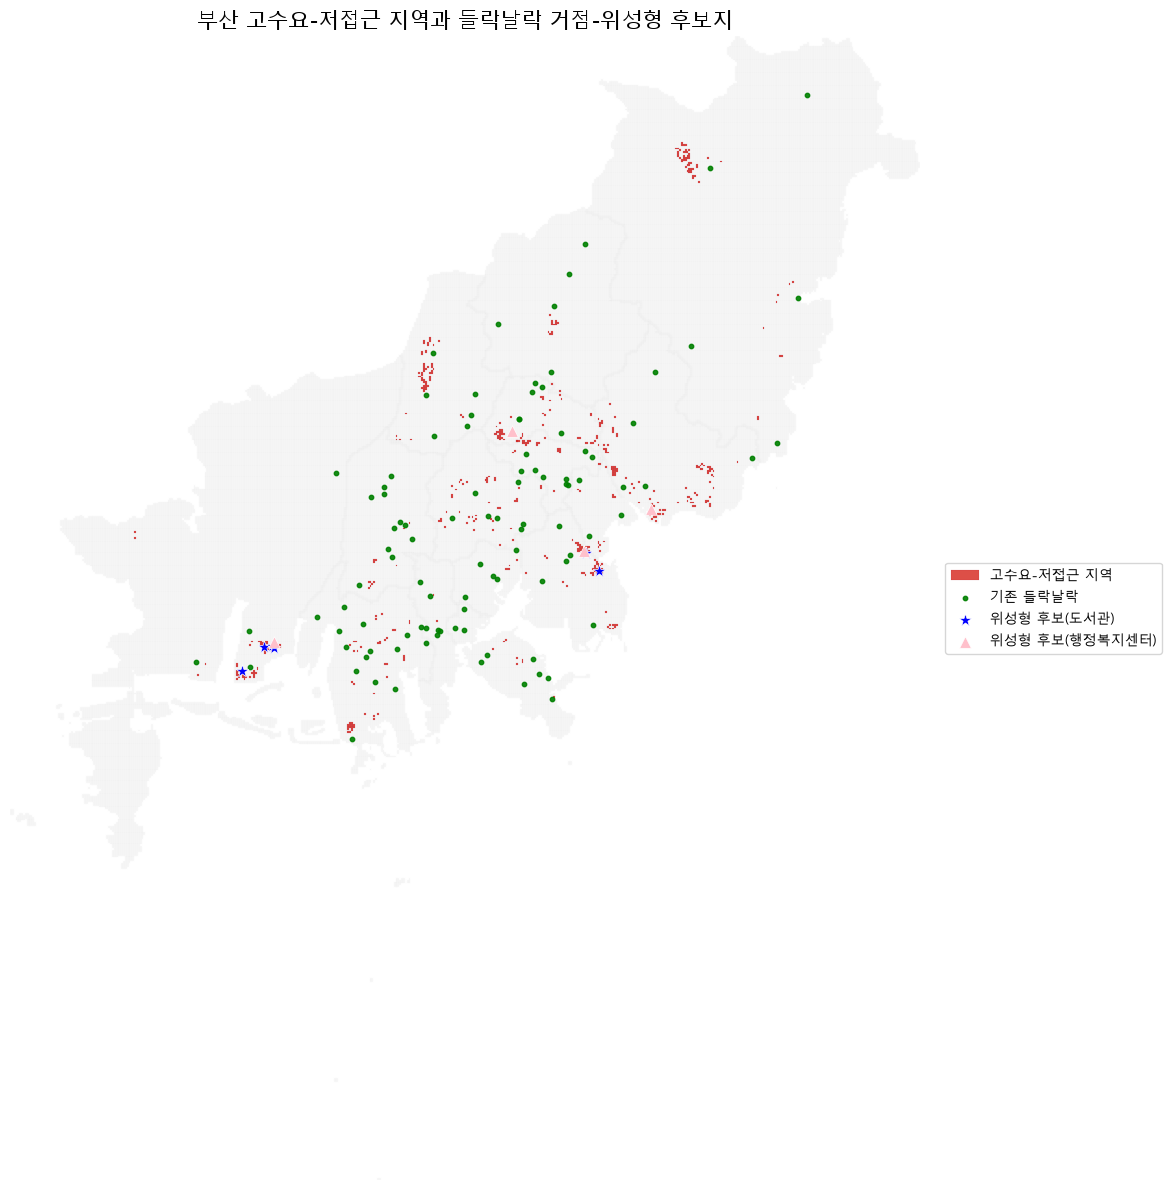

In [56]:
fig, ax = plt.subplots(figsize=(12, 12))

# --------------------------------------------------
# 1. 전체 격자 배경
# --------------------------------------------------
gdf.plot(
    ax=ax,
    color="#F2F2F2",
    edgecolor="#E6E6E6",
    linewidth=0.03,
    alpha=0.5
)

# --------------------------------------------------
# 2. 고수요-저접근성 부족지역 강조
# --------------------------------------------------
gdf[gdf["gap_type"] == "고수요-저접근성"].plot(
    ax=ax,
    color="#D73027",
    edgecolor="#A50026",
    linewidth=0.08,
    alpha=0.85,
    label="고수요-저접근 지역",
    zorder=5
)

# --------------------------------------------------
# 3. 기존 들락날락 표시
# --------------------------------------------------
dlnl_gdf.to_crs(gdf.crs).plot(
    ax=ax,
    color="green",
    markersize=10,
    marker="o",
    alpha=0.9,
    label="기존 들락날락",
    zorder=10
)

# --------------------------------------------------
# 4. 위성형 후보를 유형별로 분리
# --------------------------------------------------
satellite_selected = satellite_selected.to_crs(gdf.crs)

library_selected = satellite_selected[
    satellite_selected["candidate_type"] == "도서관"
].copy()

admin_selected = satellite_selected[
    satellite_selected["candidate_type"] == "행정복지센터"
].copy()

# --------------------------------------------------
# 5. 도서관 후보 표시
# --------------------------------------------------
if not library_selected.empty:
    library_selected.plot(
        ax=ax,
        color="blue",
        markersize=90,
        marker="*",
        edgecolor="white",
        linewidth=0.5,
        alpha=1.0,
        label="위성형 후보(도서관)",
        zorder=11
    )

# --------------------------------------------------
# 6. 행정복지센터 후보 표시
# --------------------------------------------------
if not admin_selected.empty:
    admin_selected.plot(
        ax=ax,
        color="pink",
        markersize=70,
        marker="^",
        edgecolor="white",
        linewidth=0.5,
        alpha=1.0,
        label="위성형 후보(행정복지센터)",
        zorder=12
    )

# --------------------------------------------------
# 8. 지도 범위 설정
# --------------------------------------------------
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# --------------------------------------------------
# 9. 제목 / 범례 / 축 제거
# --------------------------------------------------
ax.set_title(
    "부산 고수요-저접근 지역과 들락날락 거점-위성형 후보지",
    fontsize=15
)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    "부산_고수요_저접근_들락날락_거점_위성형_지도.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
print("지도에 표시된 위성형 후보지 수:", len(satellite_selected))

지도에 표시된 위성형 후보지 수: 10
